# Question Classification with Sentence Embeddings 

1. Build train / test / holdout splits  
2. Embed each question into a feature vector  
3. Formulate supervised learning as learning a linear map  
4. Convert labels to one-hot vectors  
5. Train a **PyTorch linear multiclass model** with `nn.Linear(...)`  
6. Use `argmax` for inference  
7. Evaluate train / test / holdout generalization with accuracy, macro F1, log loss, and confusion matrices  
8. Test a hypothesis by adding targeted examples from the holdout set and retraining


In [1]:
!pip install -q sentence-transformers torch scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    log_loss,
)

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_context("talk")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)


## Step 1: Load and inspect the data

In [3]:
train_df = pd.read_csv('question_classificatrion/question_classification_dataset/train.csv')
test_df = pd.read_csv('question_classificatrion/question_classification_dataset/test.csv')

print("Provided train shape:", train_df.shape)
print("Provided test shape:", test_df.shape)
display(train_df.head())

print("\nNumber of coarse labels:", train_df["label-coarse"].nunique())
print("Number of fine labels:", train_df["label-fine"].nunique())

Provided train shape: (5452, 3)
Provided test shape: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?



Number of coarse labels: 6
Number of fine labels: 47


## Step 2: Split the provided train set and keep the provided test set

The codex emphasizes:
- training data is used to fit the model,
- test data is used to check whether the learned relationship generalizes,
- and truly unseen data should stay independent until the end. fileciteturn1file4

We keep the provided **test.csv** intact and split **train.csv** into a 70/30 train/holdout split so the holdout remains fully unseen.


In [4]:
test_split_df = test_df.copy()

train_split_df, holdout_df = train_test_split(
    train_df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=train_df["label-fine"]
)

print("Train shape:", train_split_df.shape)
print("Test shape (provided):", test_split_df.shape)
print("Holdout shape:", holdout_df.shape)

print("\nTrain fine-label distribution:")
display(train_split_df["label-fine"].value_counts().sort_index())

print("\nTest fine-label distribution:")
display(test_split_df["label-fine"].value_counts().sort_index())

print("\nHoldout fine-label distribution:")
display(holdout_df["label-fine"].value_counts().sort_index())

Combined shape: (5952, 3)
Train shape: (1488, 3)
Test shape: (1488, 3)
Holdout shape: (2976, 3)

Train fine-label distribution:


label-fine
0      70
1      51
2      32
3      20
4     254
5      49
6       6
7     136
8      66
9      50
10     15
11     18
12     83
13     93
14    201
15      2
16      1
17     27
18     40
19     12
20     25
21     37
22      4
23     27
24      6
25     19
26     11
27     20
28     14
29     16
30      4
31     10
32      3
33      3
34      4
35      4
36      6
37      4
38      8
39      2
40     13
41      3
42      3
43      2
44      8
45      4
46      2
Name: count, dtype: int64


Test fine-label distribution:


label-fine
0      69
1      52
2      32
3      19
4     255
5      49
6       7
7     136
8      66
9      49
10     14
11     18
12     83
13     93
14    202
15      2
16      1
17     27
18     39
19     13
20     25
21     37
22      5
23     26
24      6
25     18
26     12
27     21
28     14
29     15
30      5
31      9
32      3
33      3
34      4
35      4
36      7
37      5
38      7
39      2
40     12
41      3
42      3
43      1
44      8
45      4
46      3
Name: count, dtype: int64


Holdout fine-label distribution:


label-fine
0     139
1     104
2      64
3      39
4     508
5      97
6      13
7     272
8     133
9      98
10     29
11     37
12    165
13    186
14    404
15      5
16      2
17     53
18     79
19     25
20     50
21     73
22      9
23     52
24     12
25     37
26     23
27     42
28     28
29     32
30      9
31     20
32      7
33      5
34      9
35      7
36     13
37      9
38     15
39      5
40     25
41      7
42      5
43      3
44     15
45      7
46      5
Name: count, dtype: int64

## Step 3: Choose two embedding models

We still use sentence embeddings, but now the embedding becomes the **input vector** `x in R^d` for the linear supervised learner.

That is exactly the codex idea near the end: first compute an embedding, then learn a linear classifier on top of the embedding space rather than on raw text directly. fileciteturn1file3


In [5]:
embedding_models = [
    "all-MiniLM-L6-v2",
    "paraphrase-MiniLM-L6-v2",
]

X_train_text = train_split_df["text"].tolist()
X_test_text = test_split_df["text"].tolist()
X_holdout_text = holdout_df["text"].tolist()

y_train_labels = train_split_df["label-fine"].to_numpy()
y_test_labels = test_split_df["label-fine"].to_numpy()
y_holdout_labels = holdout_df["label-fine"].to_numpy()

y_test_coarse = test_split_df["label-coarse"].to_numpy()
y_holdout_coarse = holdout_df["label-coarse"].to_numpy()

class_names = sorted(focused_df["label-fine"].unique().tolist())
class_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

class_names_coarse = sorted(focused_df["label-coarse"].unique().tolist())
fine_to_coarse = (
    focused_df[["label-fine", "label-coarse"]]
    .drop_duplicates()
    .set_index("label-fine")["label-coarse"]
    .to_dict()
)

print("Fine classes:", class_names)
print("Number of fine classes:", len(class_names))
print("Coarse classes:", class_names_coarse)

Fine classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]
Number of fine classes: 47
Coarse classes: [0, 1, 2, 3, 4, 5]


## Helper functions

The most important codex-aligned pieces are:

- `model_fit_pytorch(...)`: train a model with SGD / gradient descent  
- `nn.Sequential(nn.Linear(d, k))`: define the linear multiclass map  
- one-hot labels for the targets  
- `argmax(...)`: convert model outputs back into predicted class labels at inference time. fileciteturn1file2 fileciteturn4file0


In [6]:
def embed_texts(model_name, texts):
    model = SentenceTransformer(model_name)
    start = time.time()
    embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    elapsed = time.time() - start
    return embeddings, elapsed


def labels_to_index(labels, class_to_idx):
    return np.array([class_to_idx[label] for label in labels], dtype=np.int64)


def one_hot_encode(label_indices, num_classes):
    return np.eye(num_classes, dtype=np.float32)[label_indices]


def make_multiclass_tensors(X_np, y_labels, class_to_idx):
    y_idx = labels_to_index(y_labels, class_to_idx)
    y_onehot = one_hot_encode(y_idx, len(class_to_idx))

    X_tensor = torch.tensor(X_np, dtype=torch.float32).reshape(X_np.shape)
    Y_onehot_tensor = torch.tensor(y_onehot, dtype=torch.float32).reshape(y_onehot.shape)
    y_idx_tensor = torch.tensor(y_idx, dtype=torch.int64)

    return X_tensor, Y_onehot_tensor, y_idx_tensor, y_idx


def model_fit_pytorch(x_train, y_train, model, loss_criterion=nn.MSELoss(), epochs=1000, lr=0.01, log_interval=100):
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        y_pred = model(x_train)
        loss = loss_criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if log_interval and epoch % log_interval == 0:
            print(f"Epoch [{epoch}/{epochs}] | Loss: {loss_history[-1]:.6f}")

    return model, loss_history


def pytorch_model_multiclass_inference(model, X_tensor):
    model.eval()
    with torch.no_grad():
        Y_pred = model(X_tensor)
        pred_idx = torch.argmax(Y_pred, dim=1).detach().cpu().numpy()
    return Y_pred.detach().cpu().numpy(), pred_idx


def predict_proba_from_scores(score_matrix):
    # Convert linear outputs into class probabilities for log-loss evaluation.
    scores = torch.tensor(score_matrix, dtype=torch.float32)
    probs = torch.softmax(scores, dim=1).detach().cpu().numpy()
    return probs


def evaluate_multiclass_model(model, X_tensor, y_idx, split_name, class_names):
    raw_scores, pred_idx = pytorch_model_multiclass_inference(model, X_tensor)
    probs = predict_proba_from_scores(raw_scores)

    row = {
        "split": split_name,
        "accuracy": accuracy_score(y_idx, pred_idx),
        "macro_f1": f1_score(y_idx, pred_idx, average="macro"),
        "log_loss": log_loss(y_idx, probs, labels=np.arange(len(class_names))),
    }
    pred_labels = np.array([class_names[i] for i in pred_idx], dtype=object)
    return row, pred_idx, pred_labels, probs


def per_class_f1_df(y_true_idx, y_pred_idx, class_names, model_name, stage):
    f1_scores = f1_score(y_true_idx, y_pred_idx, average=None, labels=np.arange(len(class_names)), zero_division=0)
    return pd.DataFrame({
        "label-fine": class_names,
        "f1-score": f1_scores,
        "model": model_name,
        "stage": stage,
    })


def plot_metric_comparison(df, metric, title):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df, x="model", y=metric, hue="split")
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()


def plot_conf_mat(y_true, y_pred, labels, title, save_path=None):
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true") * 100

    plt.figure(figsize=(max(7, 0.6 * len(labels)), max(6, 0.55 * len(labels))))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        linewidths=0.5,
        linecolor="white",
    )
    plt.xlabel("Predicted")
    plt.ylabel("True (row %)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


def build_linear_multiclass_model(input_dim, output_dim):
    return nn.Sequential(nn.Linear(input_dim, output_dim))


def train_one_embedding_pipeline(model_name, X_train_text, X_test_text, X_holdout_text, y_train_labels, y_test_labels, y_holdout_labels, class_to_idx, class_names, epochs=2000, lr=0.02, log_interval=200):
    print(f"\n===== Running {model_name} =====")

    X_train_emb, train_embed_time = embed_texts(model_name, X_train_text)
    X_test_emb, test_embed_time = embed_texts(model_name, X_test_text)
    X_holdout_emb, holdout_embed_time = embed_texts(model_name, X_holdout_text)

    X_train_tensor, Y_train_onehot_tensor, y_train_idx_tensor, y_train_idx = make_multiclass_tensors(X_train_emb, y_train_labels, class_to_idx)
    X_test_tensor, _, _, y_test_idx = make_multiclass_tensors(X_test_emb, y_test_labels, class_to_idx)
    X_holdout_tensor, _, _, y_holdout_idx = make_multiclass_tensors(X_holdout_emb, y_holdout_labels, class_to_idx)

    linear_model = build_linear_multiclass_model(
        input_dim=X_train_tensor.shape[1],
        output_dim=Y_train_onehot_tensor.shape[1]
    )

    loss_criterion = nn.MSELoss()
    initial_loss = loss_criterion(linear_model(X_train_tensor), Y_train_onehot_tensor).item()
    print(f"Initial training loss: {initial_loss:.6f}")

    start = time.time()
    trained_model, loss_history = model_fit_pytorch(
        X_train_tensor,
        Y_train_onehot_tensor,
        linear_model,
        loss_criterion=loss_criterion,
        epochs=epochs,
        lr=lr,
        log_interval=log_interval
    )
    fit_time = time.time() - start

    rows = []
    train_row, train_pred_idx, train_pred_labels, train_probs = evaluate_multiclass_model(trained_model, X_train_tensor, y_train_idx, "train", class_names)
    test_row, test_pred_idx, test_pred_labels, test_probs = evaluate_multiclass_model(trained_model, X_test_tensor, y_test_idx, "test", class_names)
    holdout_row, holdout_pred_idx, holdout_pred_labels, holdout_probs = evaluate_multiclass_model(trained_model, X_holdout_tensor, y_holdout_idx, "holdout", class_names)

    rows.extend([train_row, test_row, holdout_row])
    metrics_df = pd.DataFrame(rows)
    metrics_df["model"] = model_name
    metrics_df["embed_time_train_sec"] = train_embed_time
    metrics_df["embed_time_test_sec"] = test_embed_time
    metrics_df["embed_time_holdout_sec"] = holdout_embed_time
    metrics_df["fit_time_sec"] = fit_time
    metrics_df["initial_train_loss"] = initial_loss
    metrics_df["final_train_loss"] = loss_history[-1]

    artifacts = {
        "model_name": model_name,
        "trained_model": trained_model,
        "loss_history": loss_history,
        "X_train_emb": X_train_emb,
        "X_test_emb": X_test_emb,
        "X_holdout_emb": X_holdout_emb,
        "X_train_tensor": X_train_tensor,
        "X_test_tensor": X_test_tensor,
        "X_holdout_tensor": X_holdout_tensor,
        "y_train_idx": y_train_idx,
        "y_test_idx": y_test_idx,
        "y_holdout_idx": y_holdout_idx,
        "train_pred_idx": train_pred_idx,
        "test_pred_idx": test_pred_idx,
        "holdout_pred_idx": holdout_pred_idx,
        "train_pred_labels": train_pred_labels,
        "test_pred_labels": test_pred_labels,
        "holdout_pred_labels": holdout_pred_labels,
        "train_probs": train_probs,
        "test_probs": test_probs,
        "holdout_probs": holdout_probs,
    }
    return metrics_df, artifacts


## Step 4: Embed the data and train the linear multiclass PyTorch model

This is the core codex-aligned step:

- embedding vector = input `x in R^d`
- one-hot class vector = desired output `y in R^k`
- model = `nn.Sequential(nn.Linear(d, k))`
- loss = `nn.MSELoss()`
- inference = `argmax(model(x))`

That is the same multiclass linear setup described in the codex. fileciteturn4file2 fileciteturn3file0


In [7]:
all_results = []
all_per_class = []
artifacts = {}

for model_name in embedding_models:
    metrics_df, run_artifacts = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text,
        X_test_text=X_test_text,
        X_holdout_text=X_holdout_text,
        y_train_labels=y_train_labels,
        y_test_labels=y_test_labels,
        y_holdout_labels=y_holdout_labels,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=2000,
        lr=0.02,
        log_interval=200,
    )
    all_results.append(metrics_df)

    per_class_df = per_class_f1_df(
        run_artifacts["y_test_idx"],
        run_artifacts["test_pred_idx"],
        class_names,
        model_name,
        stage="baseline"
    )
    all_per_class.append(per_class_df)
    artifacts[model_name] = run_artifacts

results_df = pd.concat(all_results, ignore_index=True)
per_class_df = pd.concat(all_per_class, ignore_index=True)

display(results_df.sort_values(["model", "split"]))


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initial training loss: 0.065001
Epoch [0/1200] | Loss: 0.065001
Epoch [200/1200] | Loss: 0.037847
Epoch [400/1200] | Loss: 0.029248
Epoch [600/1200] | Loss: 0.024615
Epoch [800/1200] | Loss: 0.021761
Epoch [1000/1200] | Loss: 0.019851


,split,accuracy,macro_f1,log_loss,model,embed_time_train_sec,embed_time_test_sec,embed_time_holdout_sec,fit_time_sec,initial_train_loss,final_train_loss
2,holdout,0.246304,0.021454,3.778599,all-MiniLM-L6-v2,1.859254,0.749384,2.148447,0.523802,0.022921,0.019563
1,test,0.247984,0.020306,3.779365,all-MiniLM-L6-v2,1.859254,0.749384,2.148447,0.523802,0.022921,0.019563
0,train,0.250672,0.023496,3.777066,all-MiniLM-L6-v2,1.859254,0.749384,2.148447,0.523802,0.022921,0.019563
5,holdout,0.495632,0.179875,3.570811,paraphrase-MiniLM-L6-v2,0.857805,0.834661,1.907812,0.479731,0.065001,0.018498
4,test,0.483871,0.174323,3.578211,paraphrase-MiniLM-L6-v2,0.857805,0.834661,1.907812,0.479731,0.065001,0.018498
3,train,0.584677,0.253196,3.527268,paraphrase-MiniLM-L6-v2,0.857805,0.834661,1.907812,0.479731,0.065001,0.018498


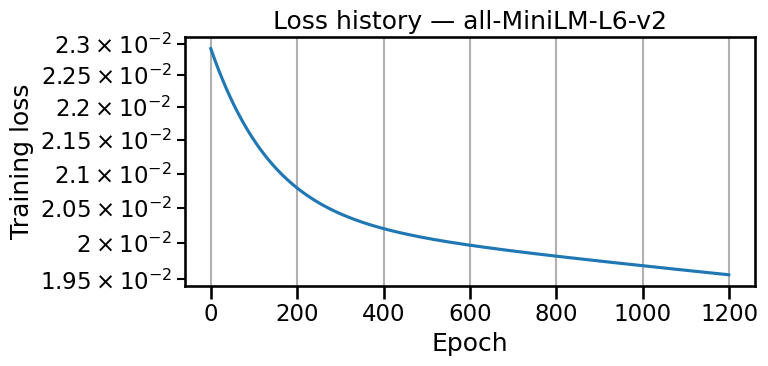

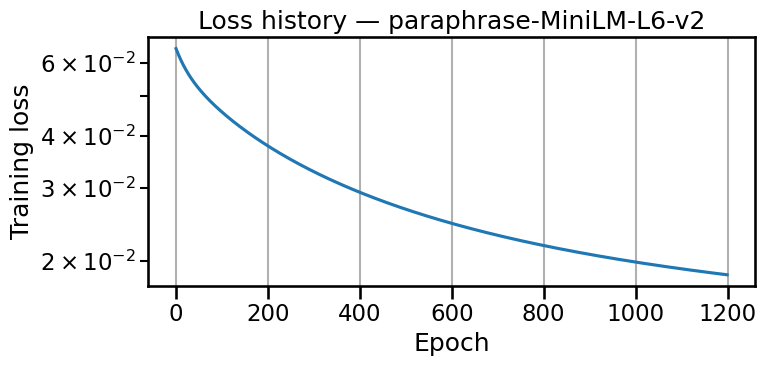

In [8]:
for model_name in embedding_models:
    loss_history = artifacts[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Step 5: Compare baseline performance

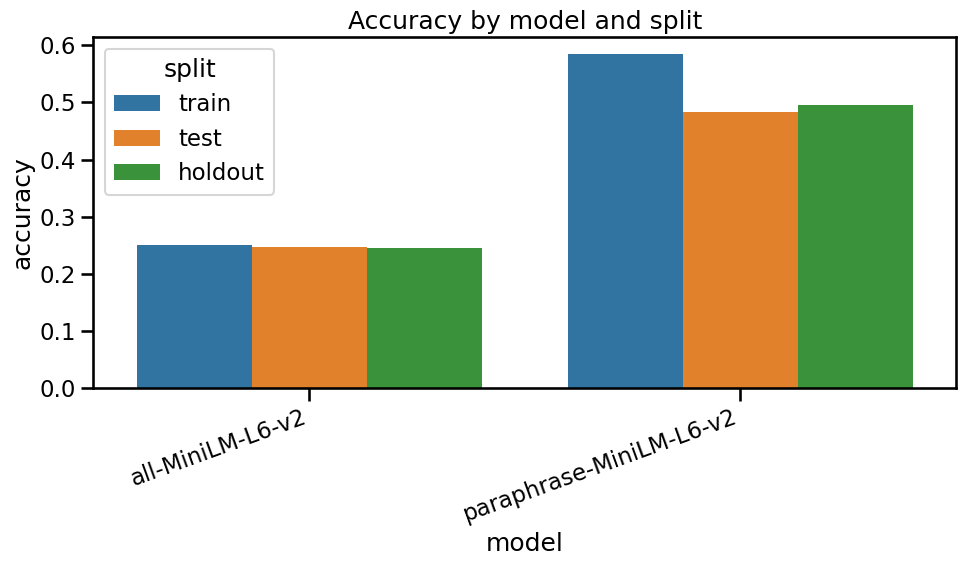

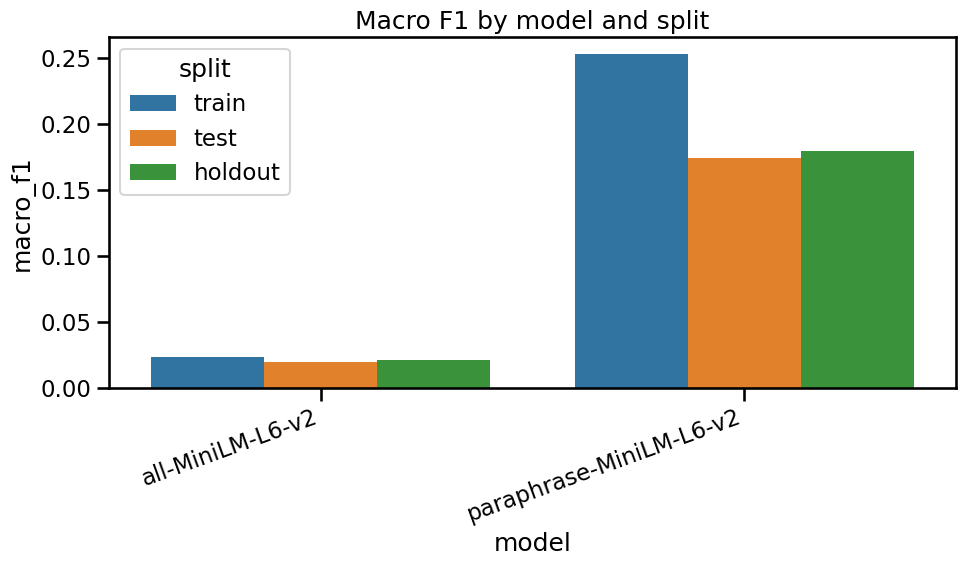

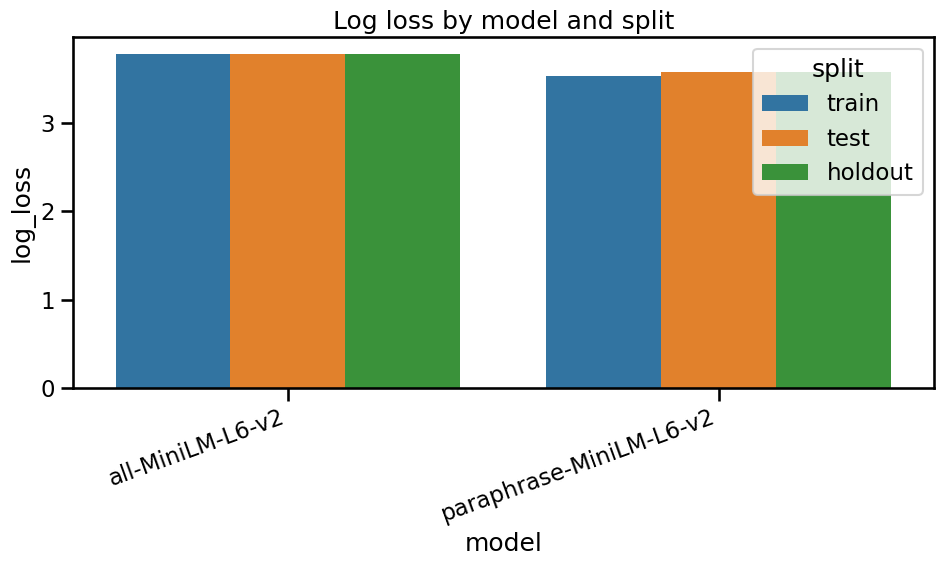

In [9]:
plot_metric_comparison(results_df, "accuracy", "Accuracy by model and split")
plot_metric_comparison(results_df, "macro_f1", "Macro F1 by model and split")
plot_metric_comparison(results_df, "log_loss", "Log loss by model and split")

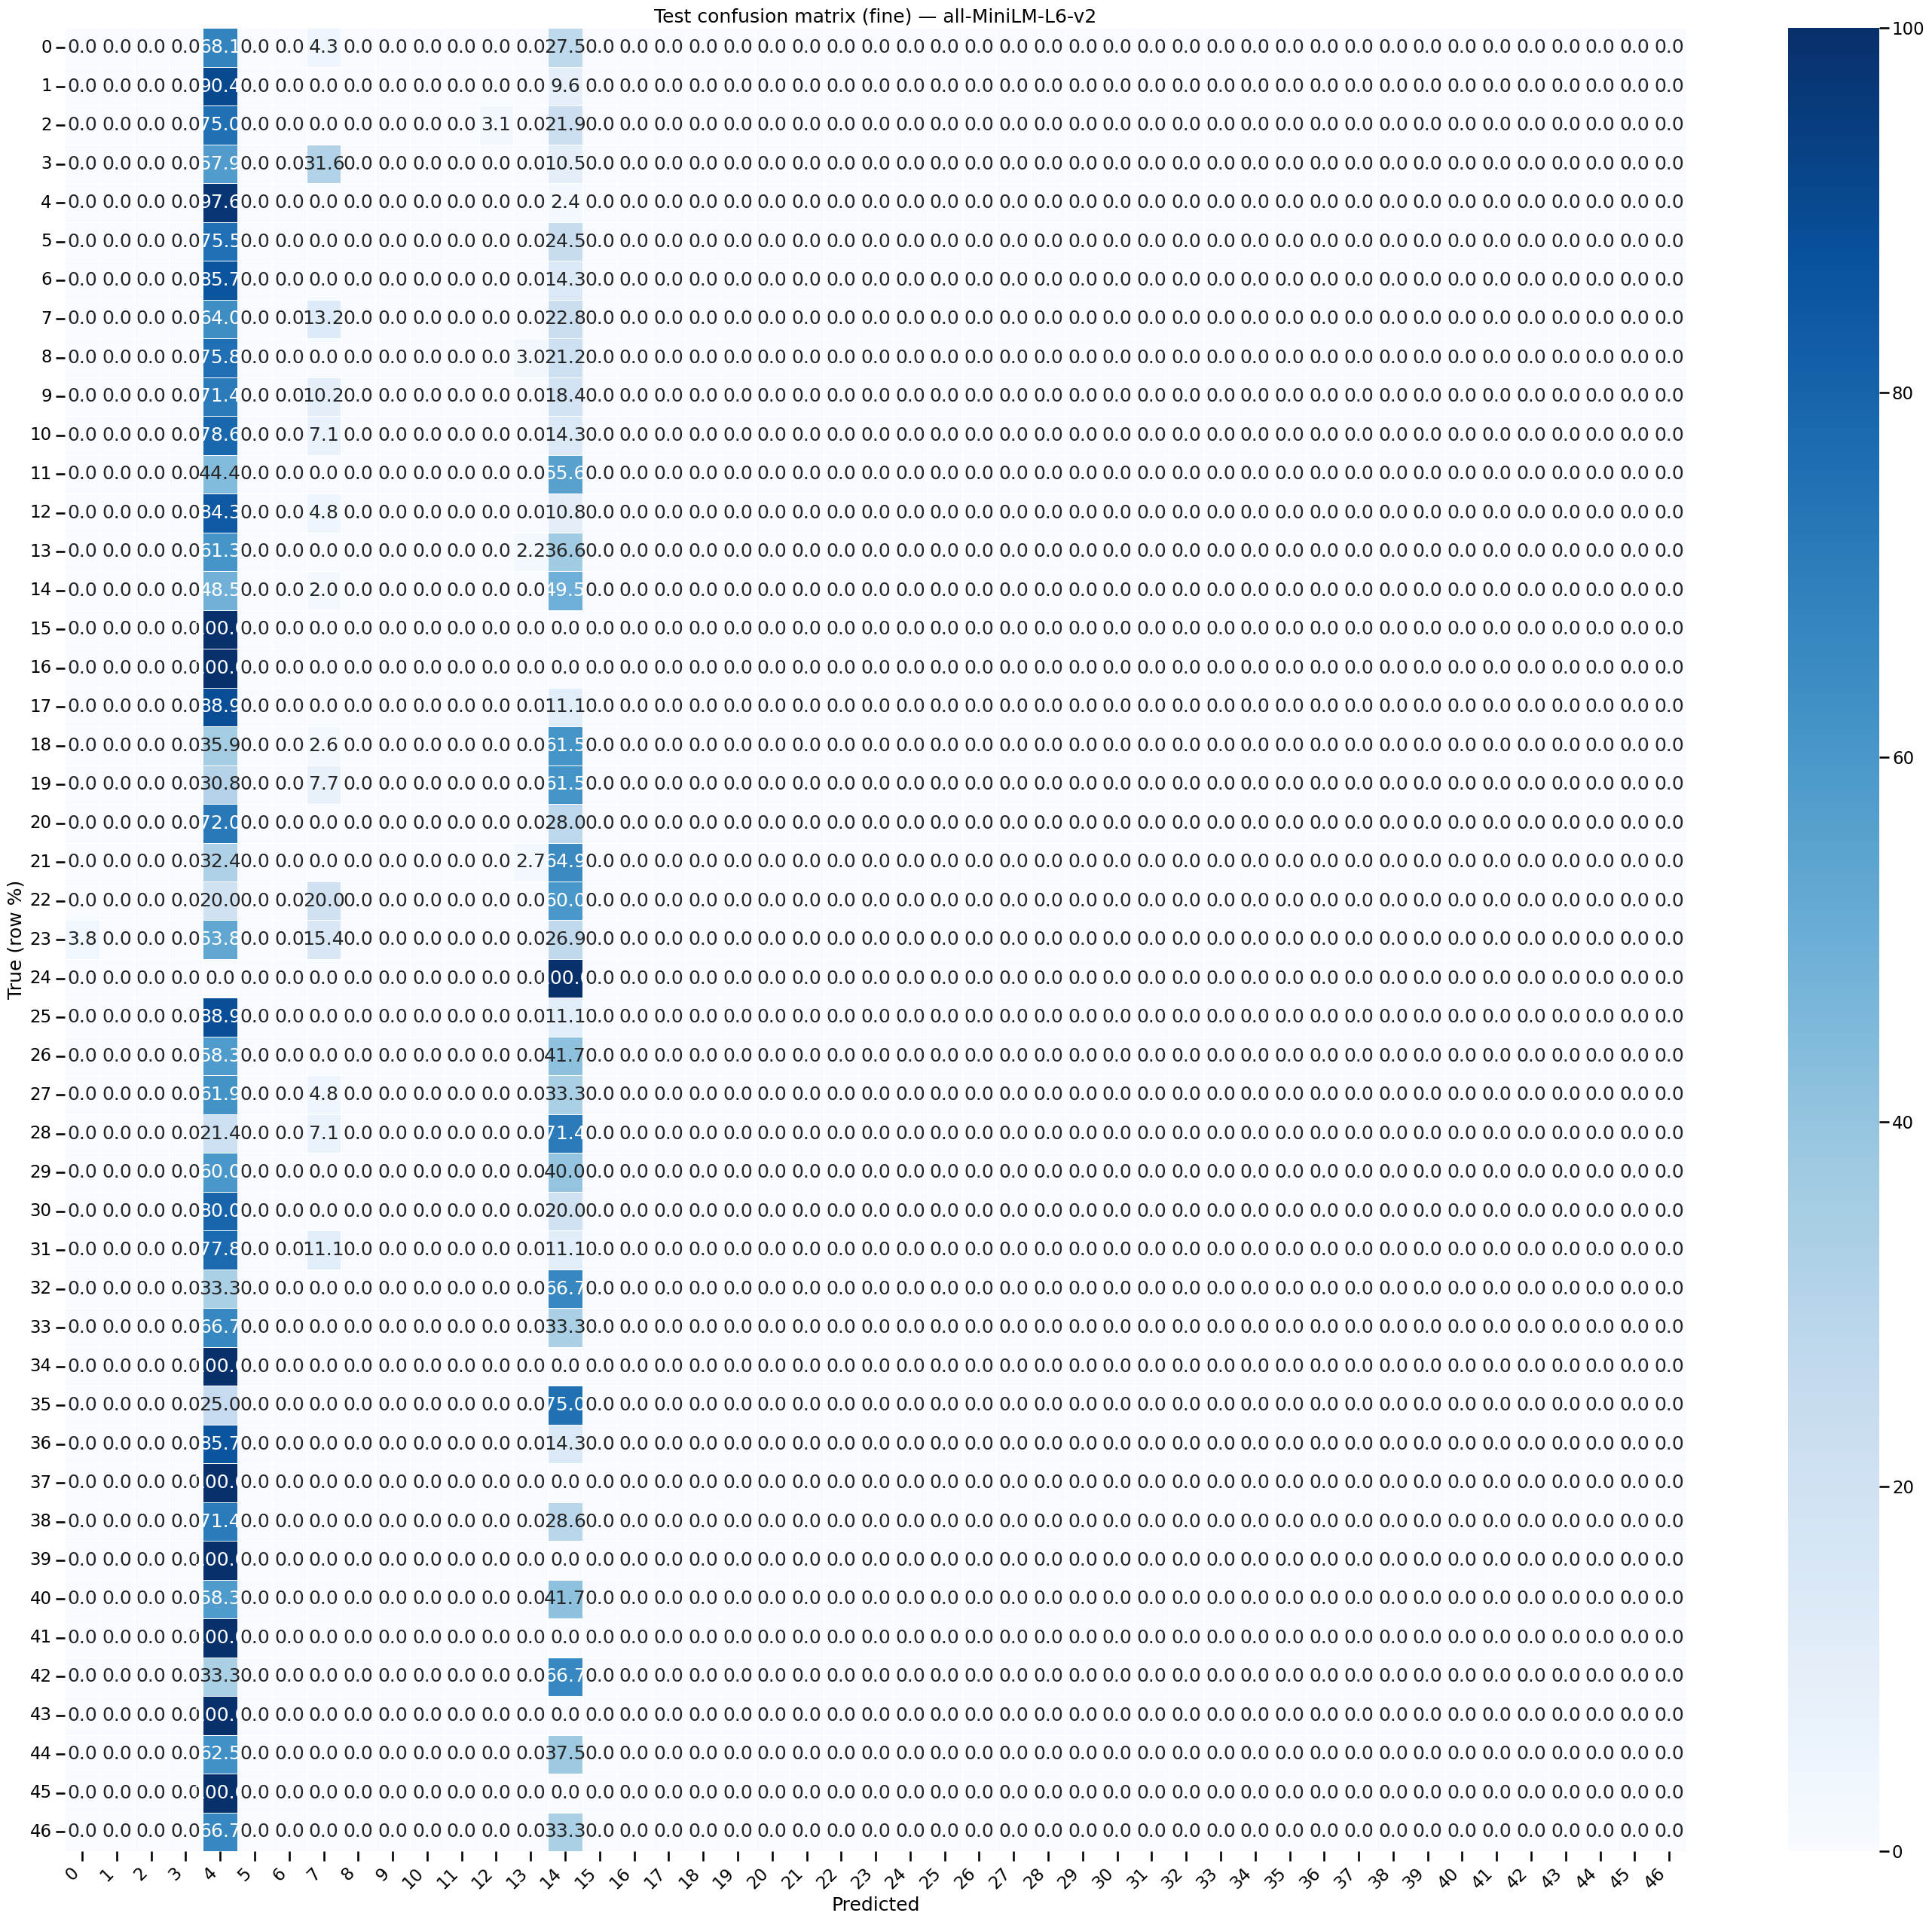

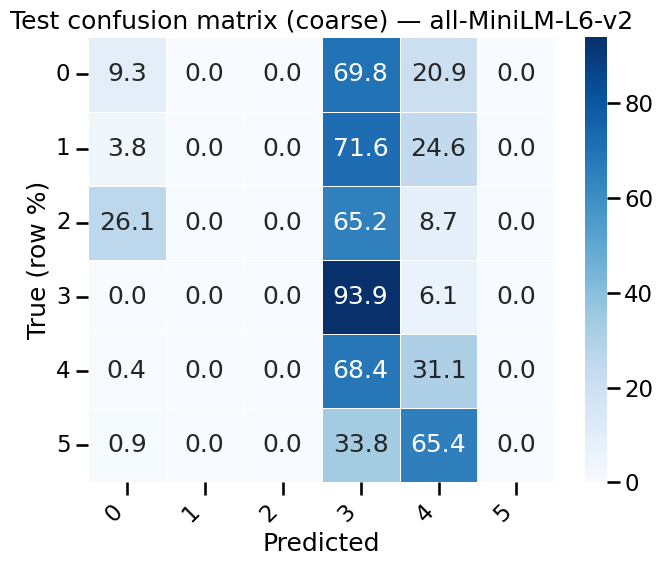

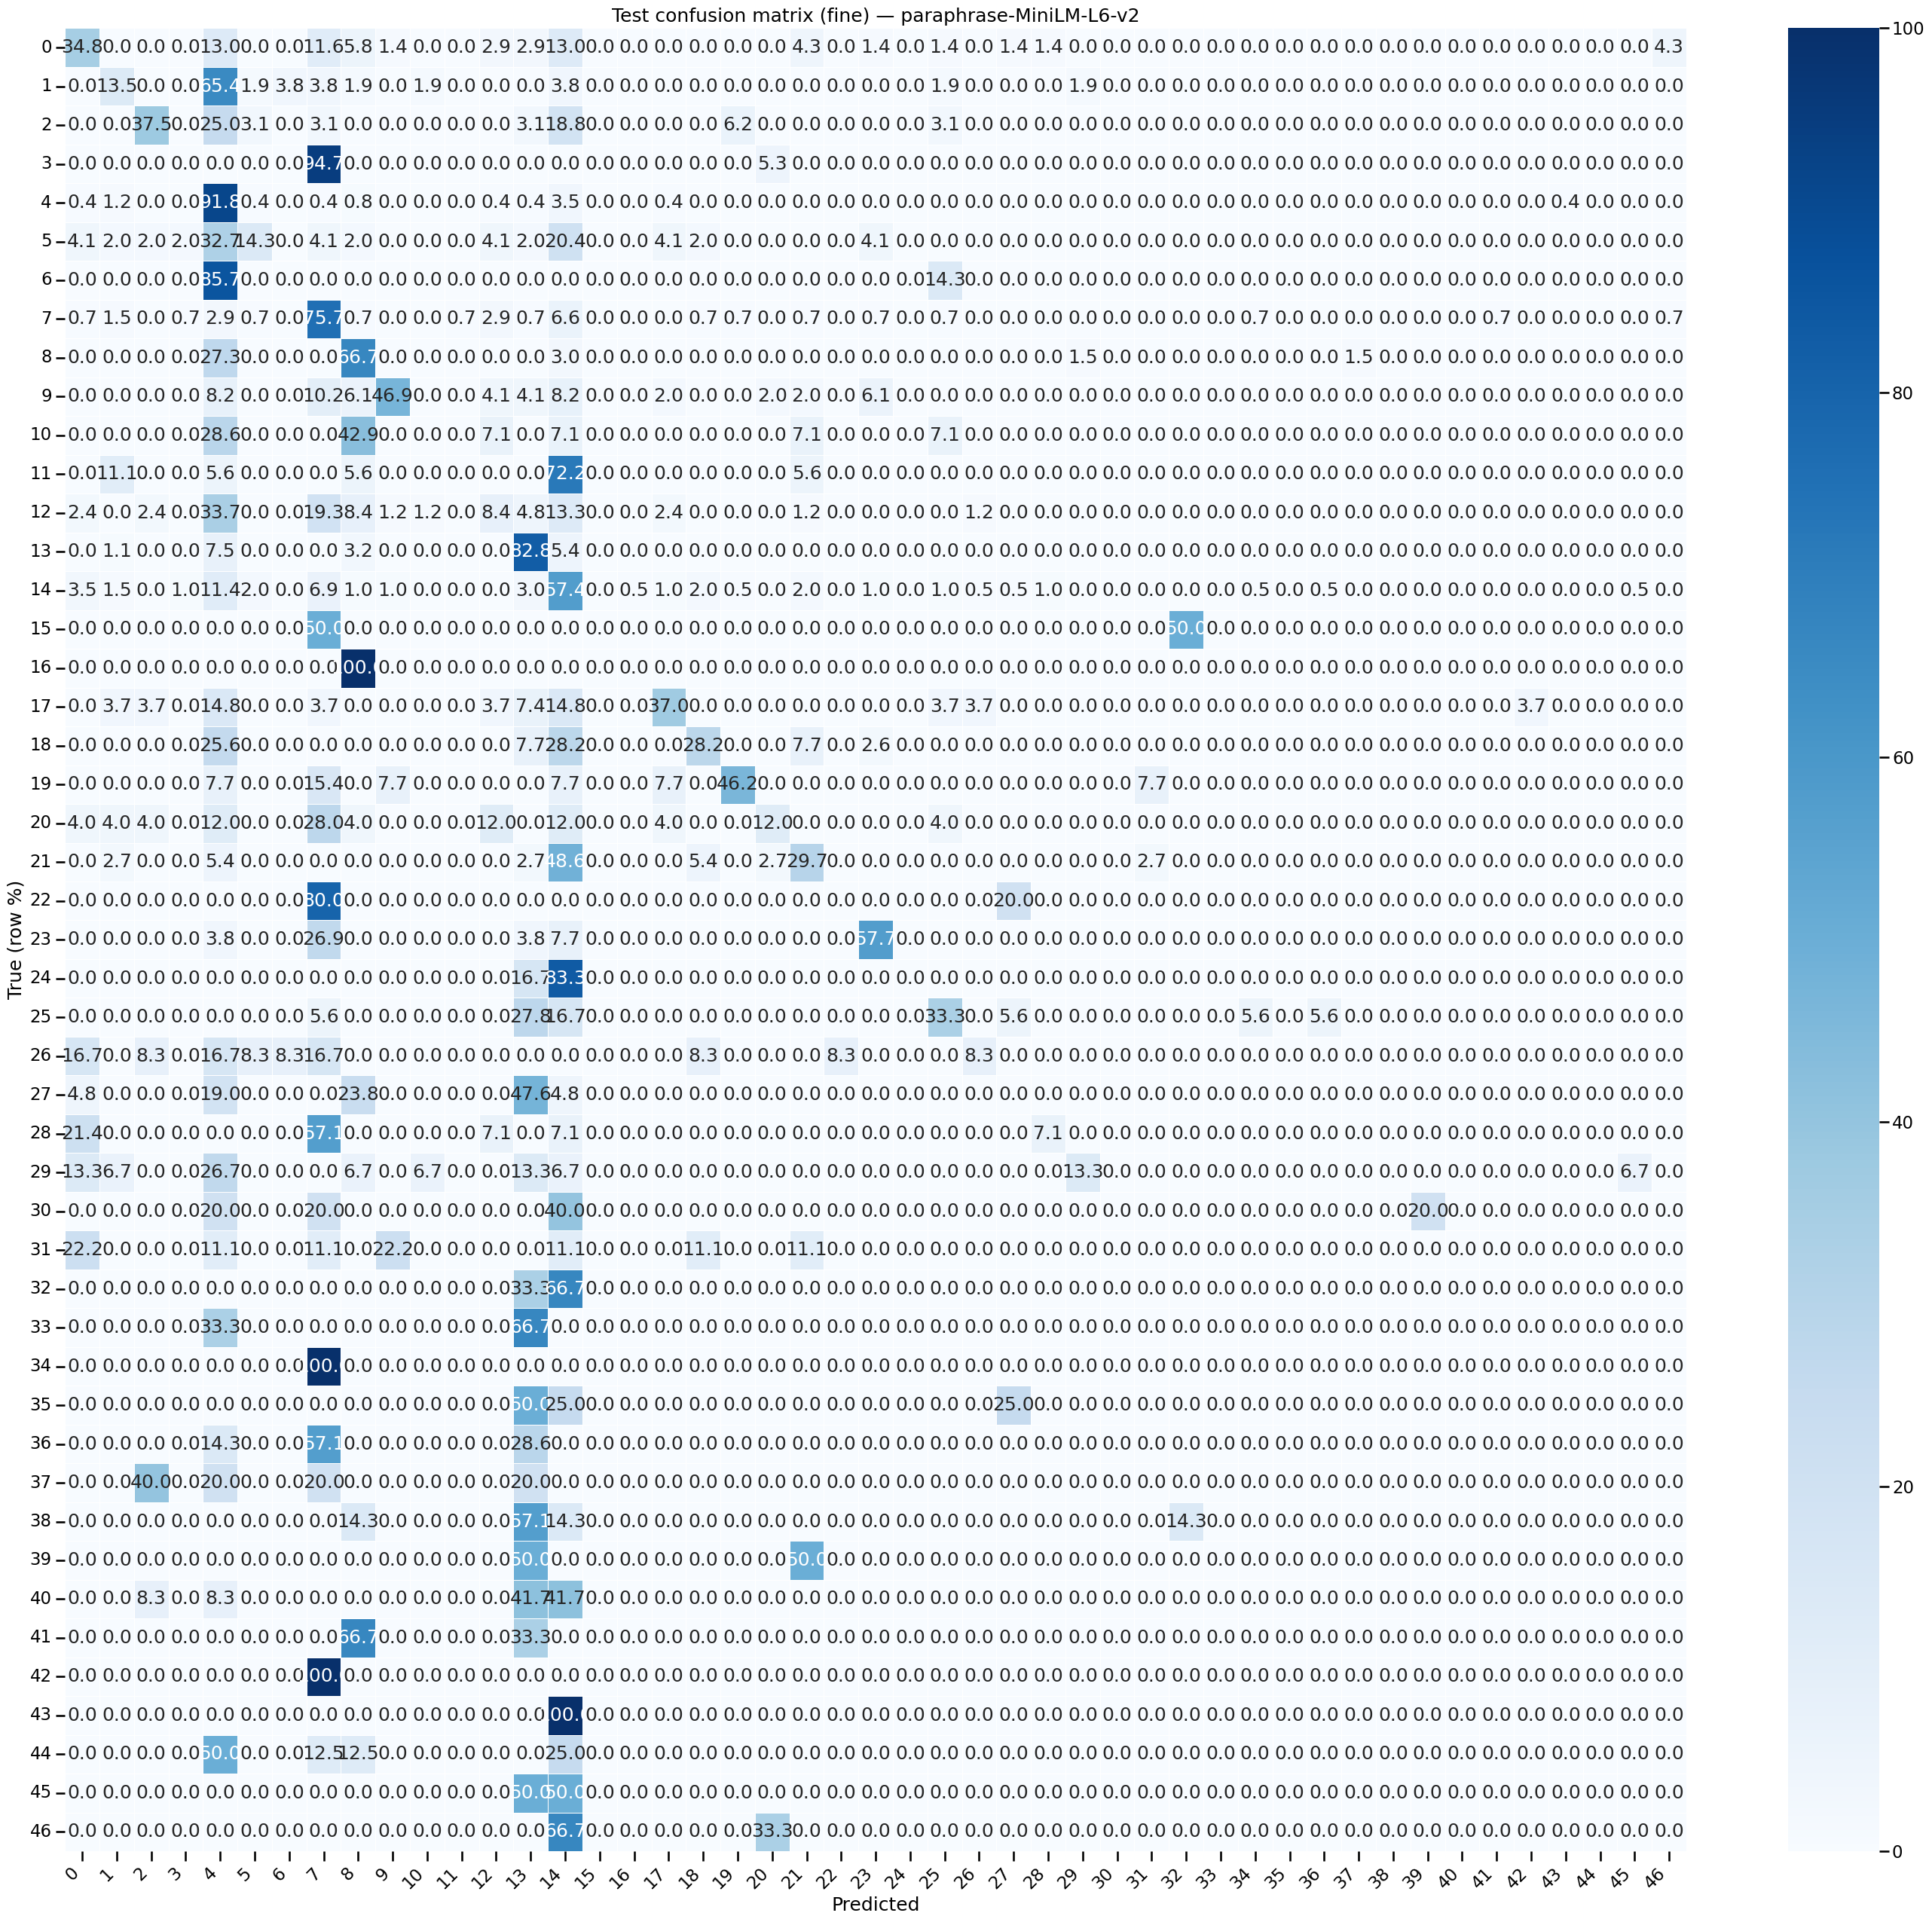

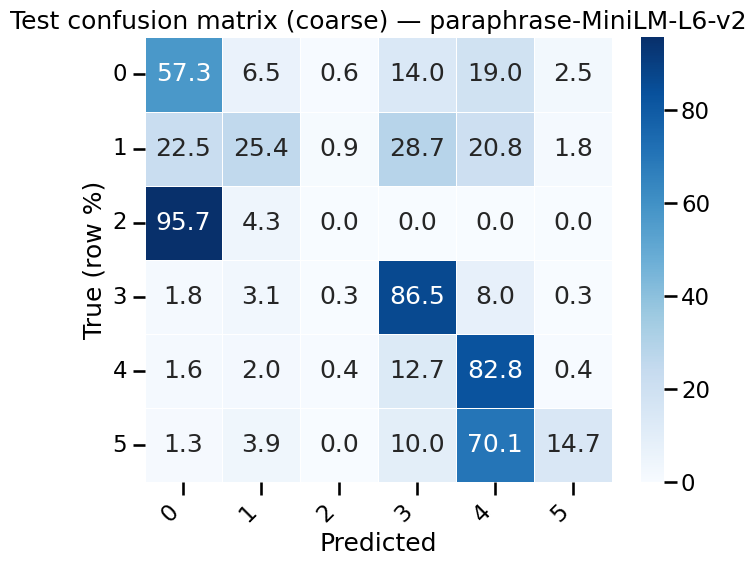

In [10]:
matrices_dir = Path("matrices")

for model_name in embedding_models:
    plot_conf_mat(
        artifacts[model_name]["y_test_idx"],
        artifacts[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix (fine) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_fine.png"
    )

    # coarse view: map predicted fine label -> coarse label
    test_pred_coarse = pd.Series(artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_coarse,
        test_pred_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix (coarse) — {model_name}",
        save_path=matrices_dir / f"baseline_{model_name}_coarse.png"
    )

## Step 8: Add targeted holdout examples for coarse labels 1, 2, and 5

These coarse labels had the lowest accuracy in the training evaluation, so we add **10% more** examples from the holdout set into the training set and remove them from holdout.

In [11]:
target_coarse_labels = [1, 2, 5]

# 10% increase relative to current training counts for these coarse labels
train_counts = train_split_df["label-coarse"].value_counts()
add_counts = (
    train_counts.reindex(target_coarse_labels).fillna(0)
    .mul(0.10)
    .apply(lambda x: int(np.ceil(x)))
)

sampled_indices = []
for cls in target_coarse_labels:
    pool = holdout_df[holdout_df["label-coarse"] == cls]
    n = min(add_counts[cls], len(pool))
    if n > 0:
        sampled_indices.extend(pool.sample(n=n, random_state=RANDOM_STATE).index)

extra_df = holdout_df.loc[sampled_indices].copy()
train_split_df = pd.concat([train_split_df, extra_df], ignore_index=True)
holdout_df = holdout_df.drop(index=sampled_indices).reset_index(drop=True)

print("Added from holdout:", extra_df.shape)
print("Train shape after augmentation:", train_split_df.shape)
print("Holdout shape after removal:", holdout_df.shape)
print("\nAdded coarse-label distribution:")
display(extra_df["label-coarse"].value_counts().sort_index())

model,label-fine,all-MiniLM-L6-v2,paraphrase-MiniLM-L6-v2,difference
46,46,0.000000,0.000000,0.000000
36,36,0.000000,0.000000,0.000000
35,35,0.000000,0.000000,0.000000
34,34,0.000000,0.000000,0.000000
33,33,0.000000,0.000000,0.000000
32,32,0.000000,0.000000,0.000000
31,31,0.000000,0.000000,0.000000
30,30,0.000000,0.000000,0.000000
27,27,0.000000,0.000000,0.000000
24,24,0.000000,0.000000,0.000000


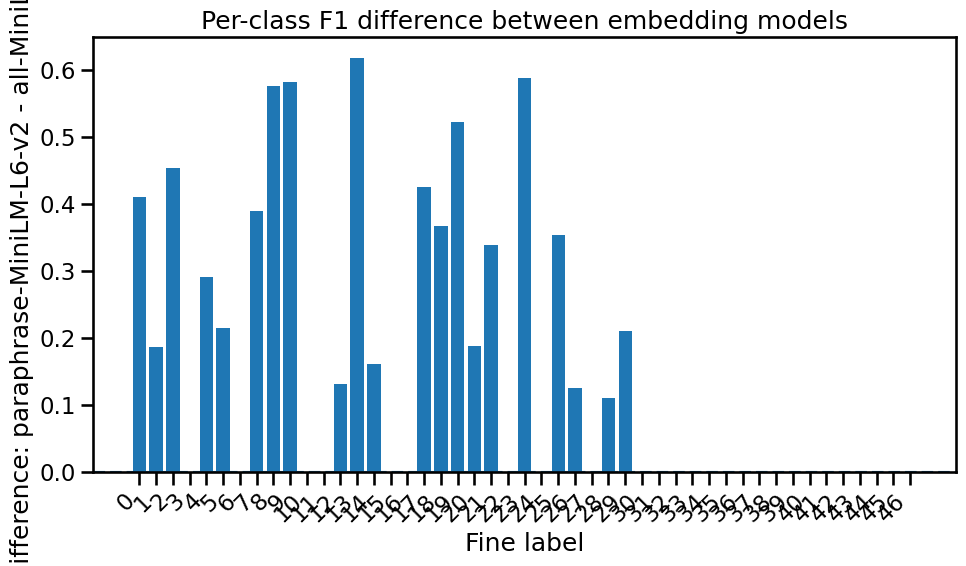

In [12]:
compare_df = (
    per_class_df
    .pivot(index="label-fine", columns="model", values="f1-score")
    .reset_index()
)

compare_df["difference"] = compare_df[embedding_models[1]] - compare_df[embedding_models[0]]
display(compare_df.sort_values("difference"))

plt.figure(figsize=(10, 6))
plt.bar(compare_df["label-fine"].astype(str), compare_df["difference"])
plt.axhline(0, linestyle="--")
plt.xlabel("Fine label")
plt.ylabel(f"F1 difference: {embedding_models[1]} - {embedding_models[0]}")
plt.title("Per-class F1 difference between embedding models")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [12]:
gen_view = results_df.pivot(index="model", columns="split", values=["accuracy", "macro_f1", "log_loss", "final_train_loss"])
display(gen_view)

accuracy                      macro_f1            \
split                     holdout      test     train   holdout      test   
model                                                                       
all-MiniLM-L6-v2         0.246304  0.247984  0.250672  0.021454  0.020306   
paraphrase-MiniLM-L6-v2  0.495632  0.483871  0.584677  0.179875  0.174323   

                                   log_loss                      \
split                       train   holdout      test     train   
model                                                             
all-MiniLM-L6-v2         0.023496  3.778599  3.779365  3.777066   
paraphrase-MiniLM-L6-v2  0.253196  3.570811  3.578211  3.527268   

                        final_train_loss                      
split                            holdout      test     train  
model                                                         
all-MiniLM-L6-v2                0.019563  0.019563  0.019563  
paraphrase-MiniLM-L6-v2         0.018498  0.018498  0.018498

In [13]:
for model_name in embedding_models:
    error_df = test_split_df.copy()
    error_df["pred"] = artifacts[model_name]["test_pred_labels"]
    error_df["correct"] = error_df["label-fine"] == error_df["pred"]

    print(f"\nSample mistakes for {model_name}")
    display(error_df.loc[~error_df["correct"], ["text", "label-fine", "pred"]].head(20))


Sample mistakes for all-MiniLM-L6-v2


,text,label-fine,pred
5301,What is the name given to the Islamic counterp...,20,14
5664,What province is Montreal in ?,11,14
5942,What is pectin ?,7,4
1978,What countries have the best math students ?,18,14
5590,What position did Willie Davis play in baseball ?,6,4
2457,Who is Count Cinzano ?,12,4
3874,"What do Hank Aaron , Jimmy Stewart , and Howar...",12,4
2428,How did people respond to the idea of the firs...,0,4
1970,What 's the most popular contact lens color ?,19,14
4890,What is the difference between love and infatu...,12,4



Sample mistakes for paraphrase-MiniLM-L6-v2


,text,label-fine,pred
5664,What province is Montreal in ?,11,14
1978,What countries have the best math students ?,18,21
5590,What position did Willie Davis play in baseball ?,6,4
2457,Who is Count Cinzano ?,12,4
3874,"What do Hank Aaron , Jimmy Stewart , and Howar...",12,13
2428,How did people respond to the idea of the firs...,0,7
4890,What is the difference between love and infatu...,12,7
5005,What Cruise Line does Kathie Lee Gifford adver...,5,4
1101,What inescapable purveyor of background music ...,5,8
4974,Who wrote the bestselling Missionary Travels a...,4,14


## Step 6: Form a hypothesis and test it with additional data

We keep your original idea:
- identify the weakest classes on the **test** set,
- pull extra examples for those classes from the **holdout** set,
- retrain,
- and compare whether the weak classes improved.

This matches the codex idea of checking whether the learned input-output relationship generalizes, then changing the training data and measuring what happens. fileciteturn1file4


In [14]:
avg_class_perf = (
    per_class_df
    .groupby("label-fine")["f1-score"]
    .mean()
    .sort_values()
)
display(avg_class_perf)

target_classes = avg_class_perf.head(2).index.tolist()
examples_per_target_class = 15

print("Target classes for added data:", target_classes)
print("Examples added per target class:", examples_per_target_class)

label-fine
46    0.000000
33    0.000000
32    0.000000
31    0.000000
30    0.000000
27    0.000000
24    0.000000
45    0.000000
22    0.000000
36    0.000000
34    0.000000
16    0.000000
15    0.000000
38    0.000000
37    0.000000
35    0.000000
11    0.000000
10    0.000000
44    0.000000
40    0.000000
3     0.000000
43    0.000000
41    0.000000
42    0.000000
6     0.000000
39    0.000000
28    0.055556
26    0.062500
12    0.065421
1     0.093333
20    0.093750
29    0.105263
5     0.107692
21    0.169231
25    0.176471
18    0.183333
0     0.205128
17    0.212766
2     0.226415
19    0.260870
8     0.287582
9     0.291139
23    0.294118
13    0.349468
7     0.387217
14    0.415367
4     0.531174
Name: f1-score, dtype: float64

Target classes for added data: [46, 33]
Examples added per target class: 15


In [15]:
holdout_for_sampling = holdout_df.copy()

sampled_extra_parts = []
sampled_indices = []

for cls in target_classes:
    class_pool = holdout_for_sampling[holdout_for_sampling["label-fine"] == cls]
    sampled = class_pool.sample(
        n=min(examples_per_target_class, len(class_pool)),
        random_state=RANDOM_STATE
    )
    sampled_extra_parts.append(sampled)
    sampled_indices.extend(sampled.index.tolist())

extra_df = pd.concat(sampled_extra_parts, ignore_index=False).copy()
remaining_holdout_df = holdout_df.drop(index=sampled_indices).copy()

print("Extra examples pulled from holdout:", extra_df.shape)
display(extra_df[["label-fine", "text"]].head(20))

print("Remaining holdout shape:", remaining_holdout_df.shape)

Extra examples pulled from holdout: (10, 3)


,label-fine,text
5451,46,What currency is used in Australia ?
5436,46,What money was used here ?
5528,46,What type of currency is used in Australia ?
2470,46,What money was used by them ?
5948,46,What is the money they use in Zambia ?
3897,33,What instrument does Benny Carter play ?
1247,33,Ray Charles plays which instrument ?
5715,33,What instrument did Glenn Miller play ?
1834,33,What kind of guitar did Jimi Hendrix play ?
3190,33,Ray Charles is best known for playing what ins...


Remaining holdout shape: (2966, 3)


In [16]:
augmented_training_pool = pd.concat([train_split_df, extra_df], axis=0).sample(frac=1.0, random_state=RANDOM_STATE)

train_split_aug = augmented_training_pool.reset_index(drop=True)
test_split_aug = test_split_df.reset_index(drop=True)
holdout_split_aug = remaining_holdout_df.reset_index(drop=True)

print("Augmented train shape:", train_split_aug.shape)
print("Test shape (unchanged):", test_split_aug.shape)
print("Holdout shape (reduced after sampling):", holdout_split_aug.shape)

Augmented train shape: (1498, 3)
Test shape (unchanged): (1488, 3)
Holdout shape (reduced after sampling): (2966, 3)


In [17]:
X_train_text_aug = train_split_aug["text"].tolist()
X_test_text_aug = test_split_aug["text"].tolist()
X_holdout_text_aug = holdout_split_aug["text"].tolist()

y_train_labels_aug = train_split_aug["label-fine"].to_numpy()
y_test_labels_aug = test_split_aug["label-fine"].to_numpy()
y_holdout_labels_aug = holdout_split_aug["label-fine"].to_numpy()

y_test_aug_coarse = test_split_aug["label-coarse"].to_numpy()
y_holdout_aug_coarse = holdout_split_aug["label-coarse"].to_numpy()

post_results = []
post_per_class = []
post_artifacts = {}

for model_name in embedding_models:
    metrics_df_aug, run_artifacts_aug = train_one_embedding_pipeline(
        model_name=model_name,
        X_train_text=X_train_text_aug,
        X_test_text=X_test_text_aug,
        X_holdout_text=X_holdout_text_aug,
        y_train_labels=y_train_labels_aug,
        y_test_labels=y_test_labels_aug,
        y_holdout_labels=y_holdout_labels_aug,
        class_to_idx=class_to_idx,
        class_names=class_names,
        epochs=2000,
        lr=0.02,
        log_interval=200,
    )
    post_results.append(metrics_df_aug)

    post_per_class_df = per_class_f1_df(
        run_artifacts_aug["y_test_idx"],
        run_artifacts_aug["test_pred_idx"],
        class_names,
        model_name,
        stage="after_augmentation"
    )
    post_per_class.append(post_per_class_df)
    post_artifacts[model_name] = run_artifacts_aug

post_results_df = pd.concat(post_results, ignore_index=True)
post_per_class_df = pd.concat(post_per_class, ignore_index=True)

display(post_results_df.sort_values(["model", "split"]))


===== Running all-MiniLM-L6-v2 =====


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Initial training loss: 0.064646
Epoch [0/1200] | Loss: 0.064646
Epoch [200/1200] | Loss: 0.036962
Epoch [400/1200] | Loss: 0.028935
Epoch [600/1200] | Loss: 0.024532
Epoch [800/1200] | Loss: 0.021780
Epoch [1000/1200] | Loss: 0.019917


,split,accuracy,macro_f1,log_loss,model,embed_time_train_sec,embed_time_test_sec,embed_time_holdout_sec,fit_time_sec,initial_train_loss,final_train_loss
2,holdout,0.247134,0.023670,3.779212,all-MiniLM-L6-v2,1.141262,1.104983,2.083874,0.481937,0.022549,0.019573
1,test,0.252688,0.022944,3.778057,all-MiniLM-L6-v2,1.141262,1.104983,2.083874,0.481937,0.022549,0.019573
0,train,0.252336,0.021896,3.777957,all-MiniLM-L6-v2,1.141262,1.104983,2.083874,0.481937,0.022549,0.019573
5,holdout,0.496966,0.176446,3.573709,paraphrase-MiniLM-L6-v2,0.795549,0.908613,1.995456,0.482321,0.064646,0.018588
4,test,0.471774,0.183714,3.577922,paraphrase-MiniLM-L6-v2,0.795549,0.908613,1.995456,0.482321,0.064646,0.018588
3,train,0.588117,0.304813,3.528570,paraphrase-MiniLM-L6-v2,0.795549,0.908613,1.995456,0.482321,0.064646,0.018588


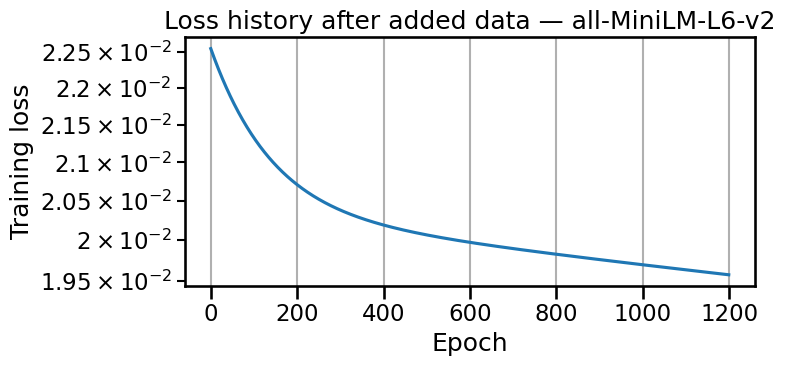

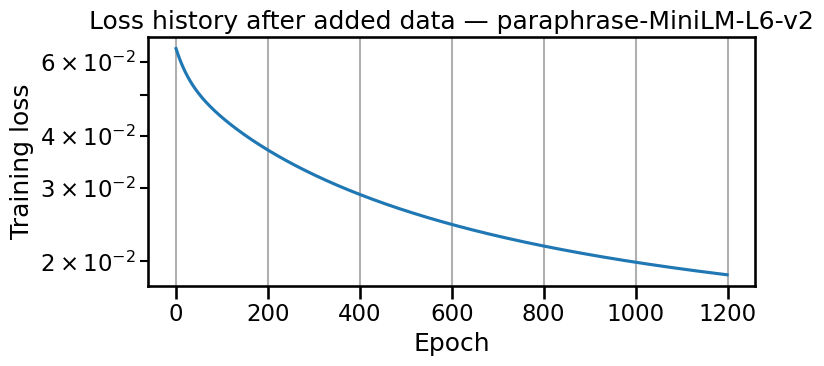

In [18]:
for model_name in embedding_models:
    loss_history = post_artifacts[model_name]["loss_history"]
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(loss_history)), loss_history)
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title(f"Loss history after added data — {model_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

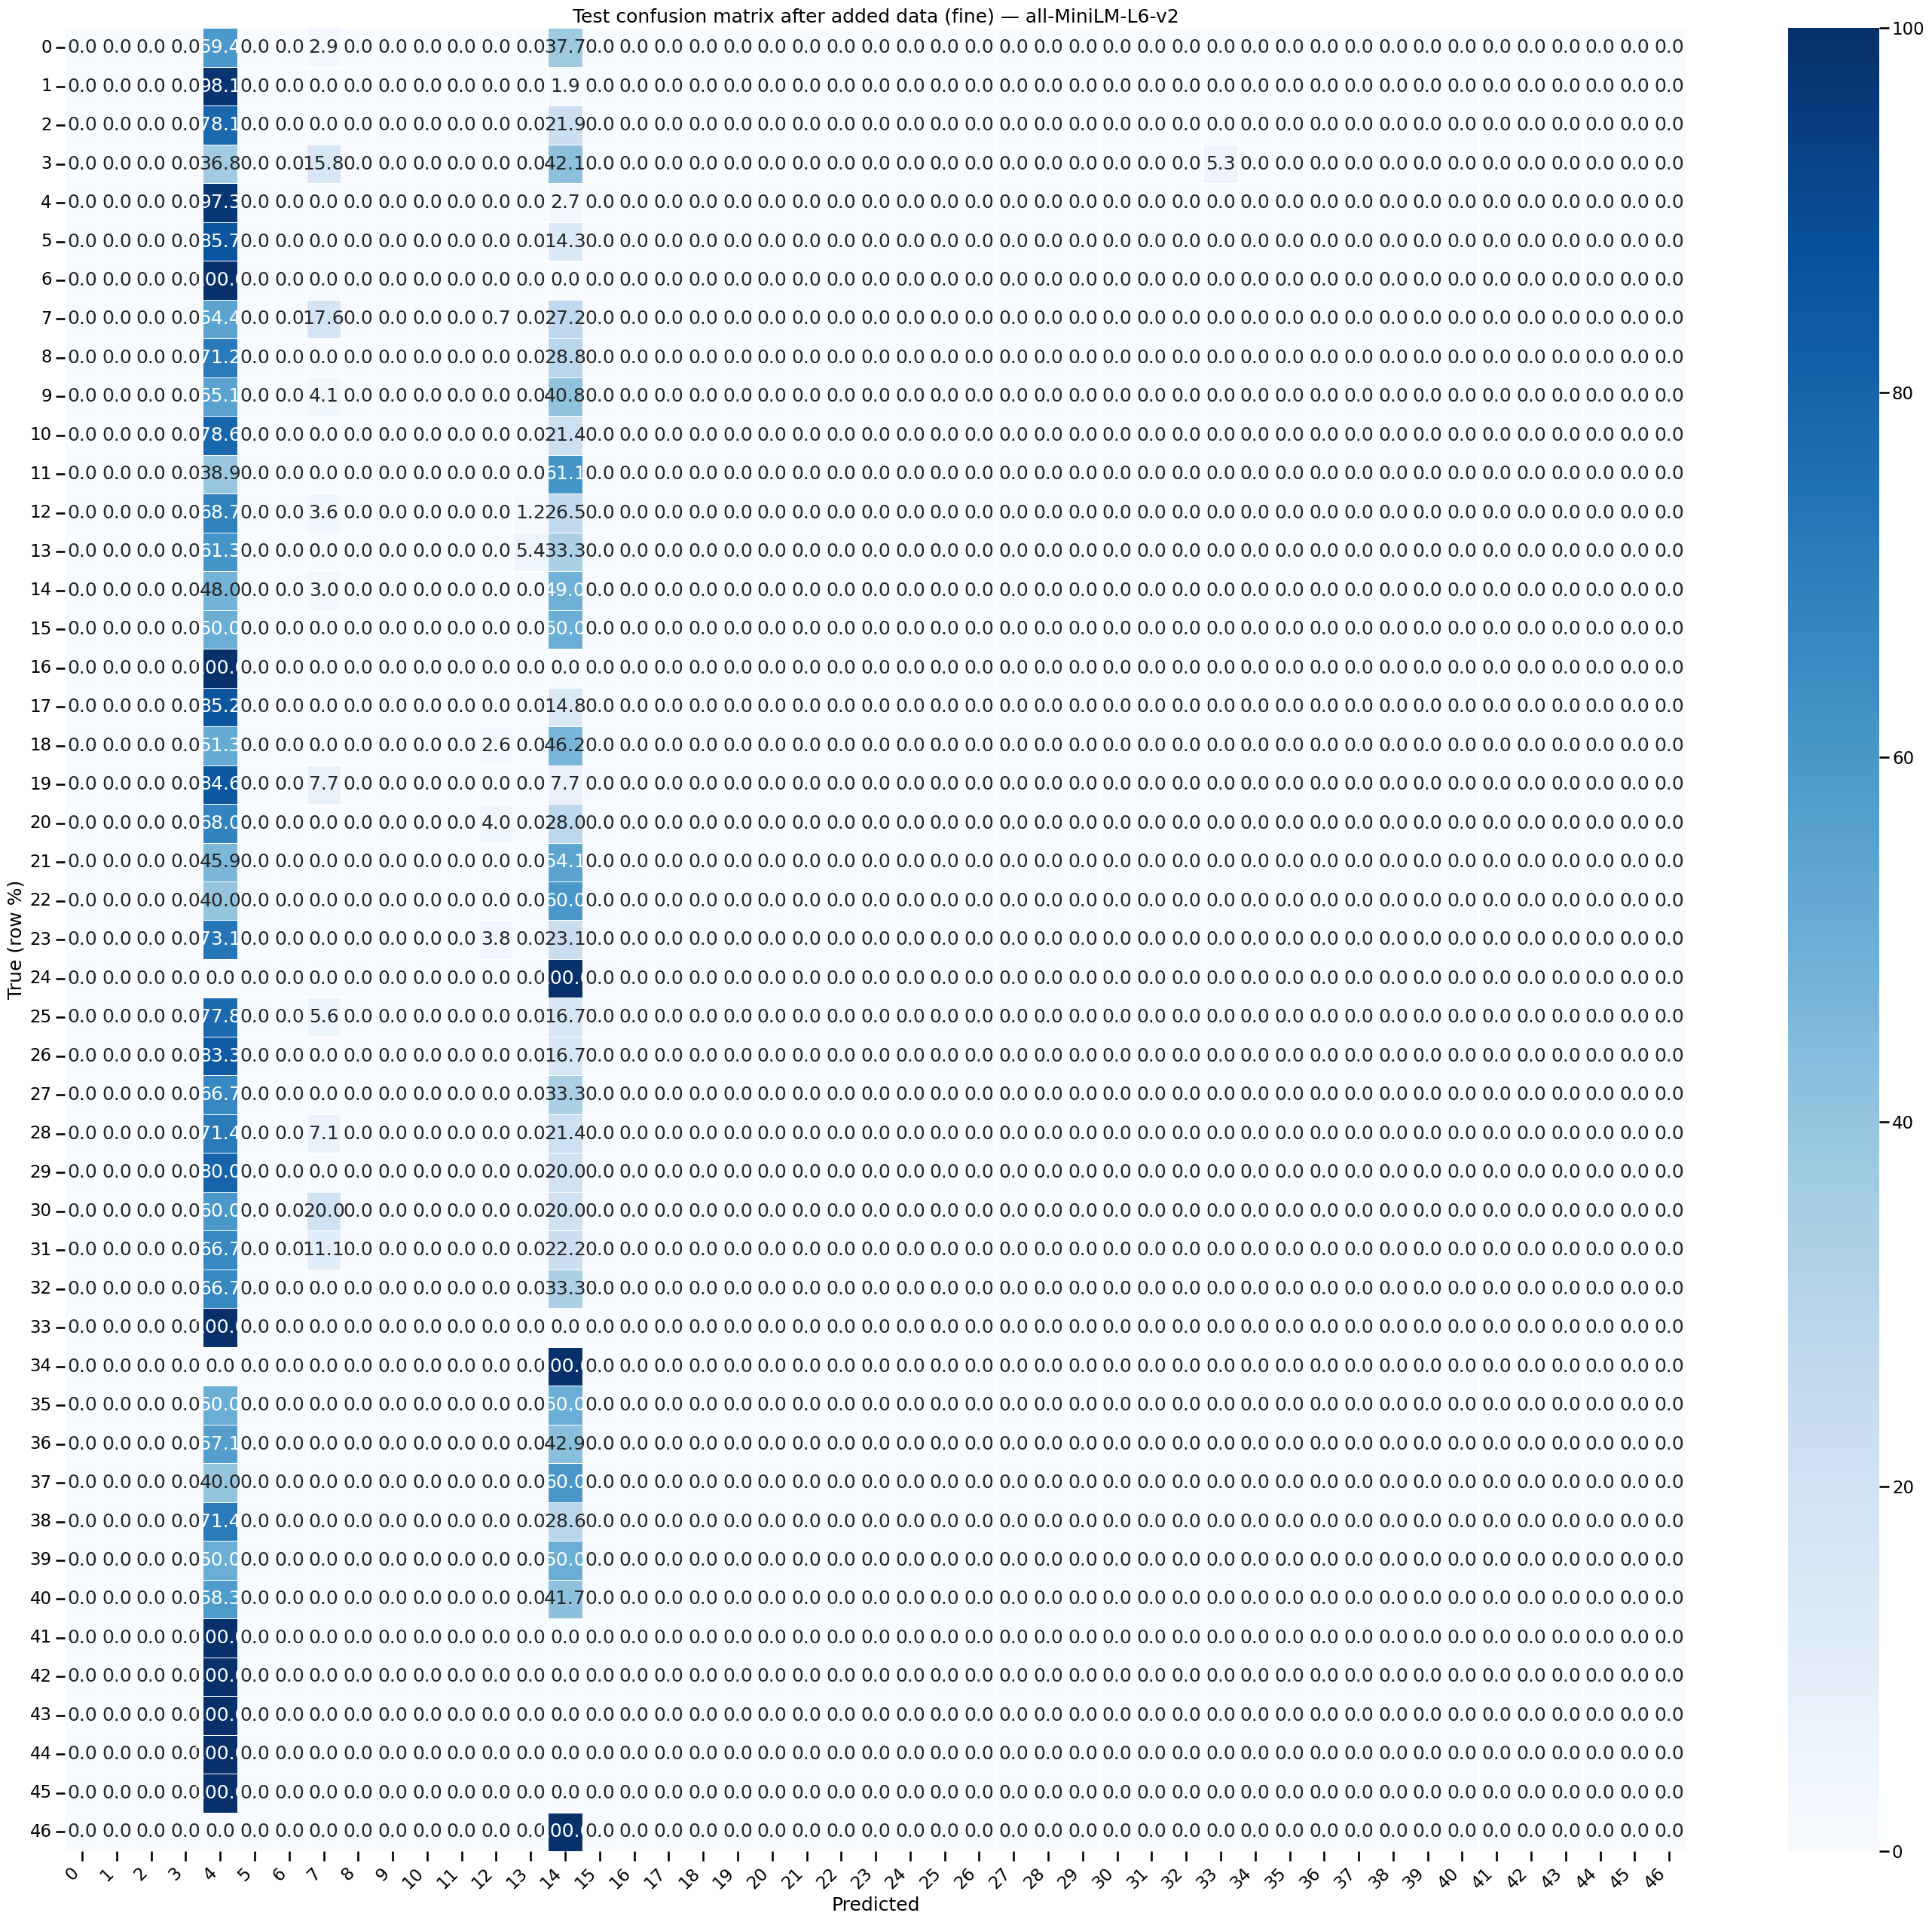

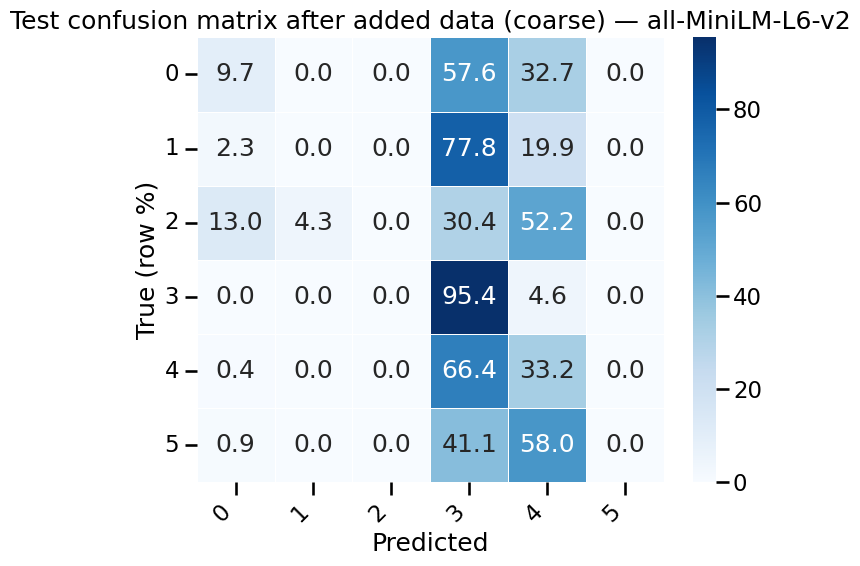

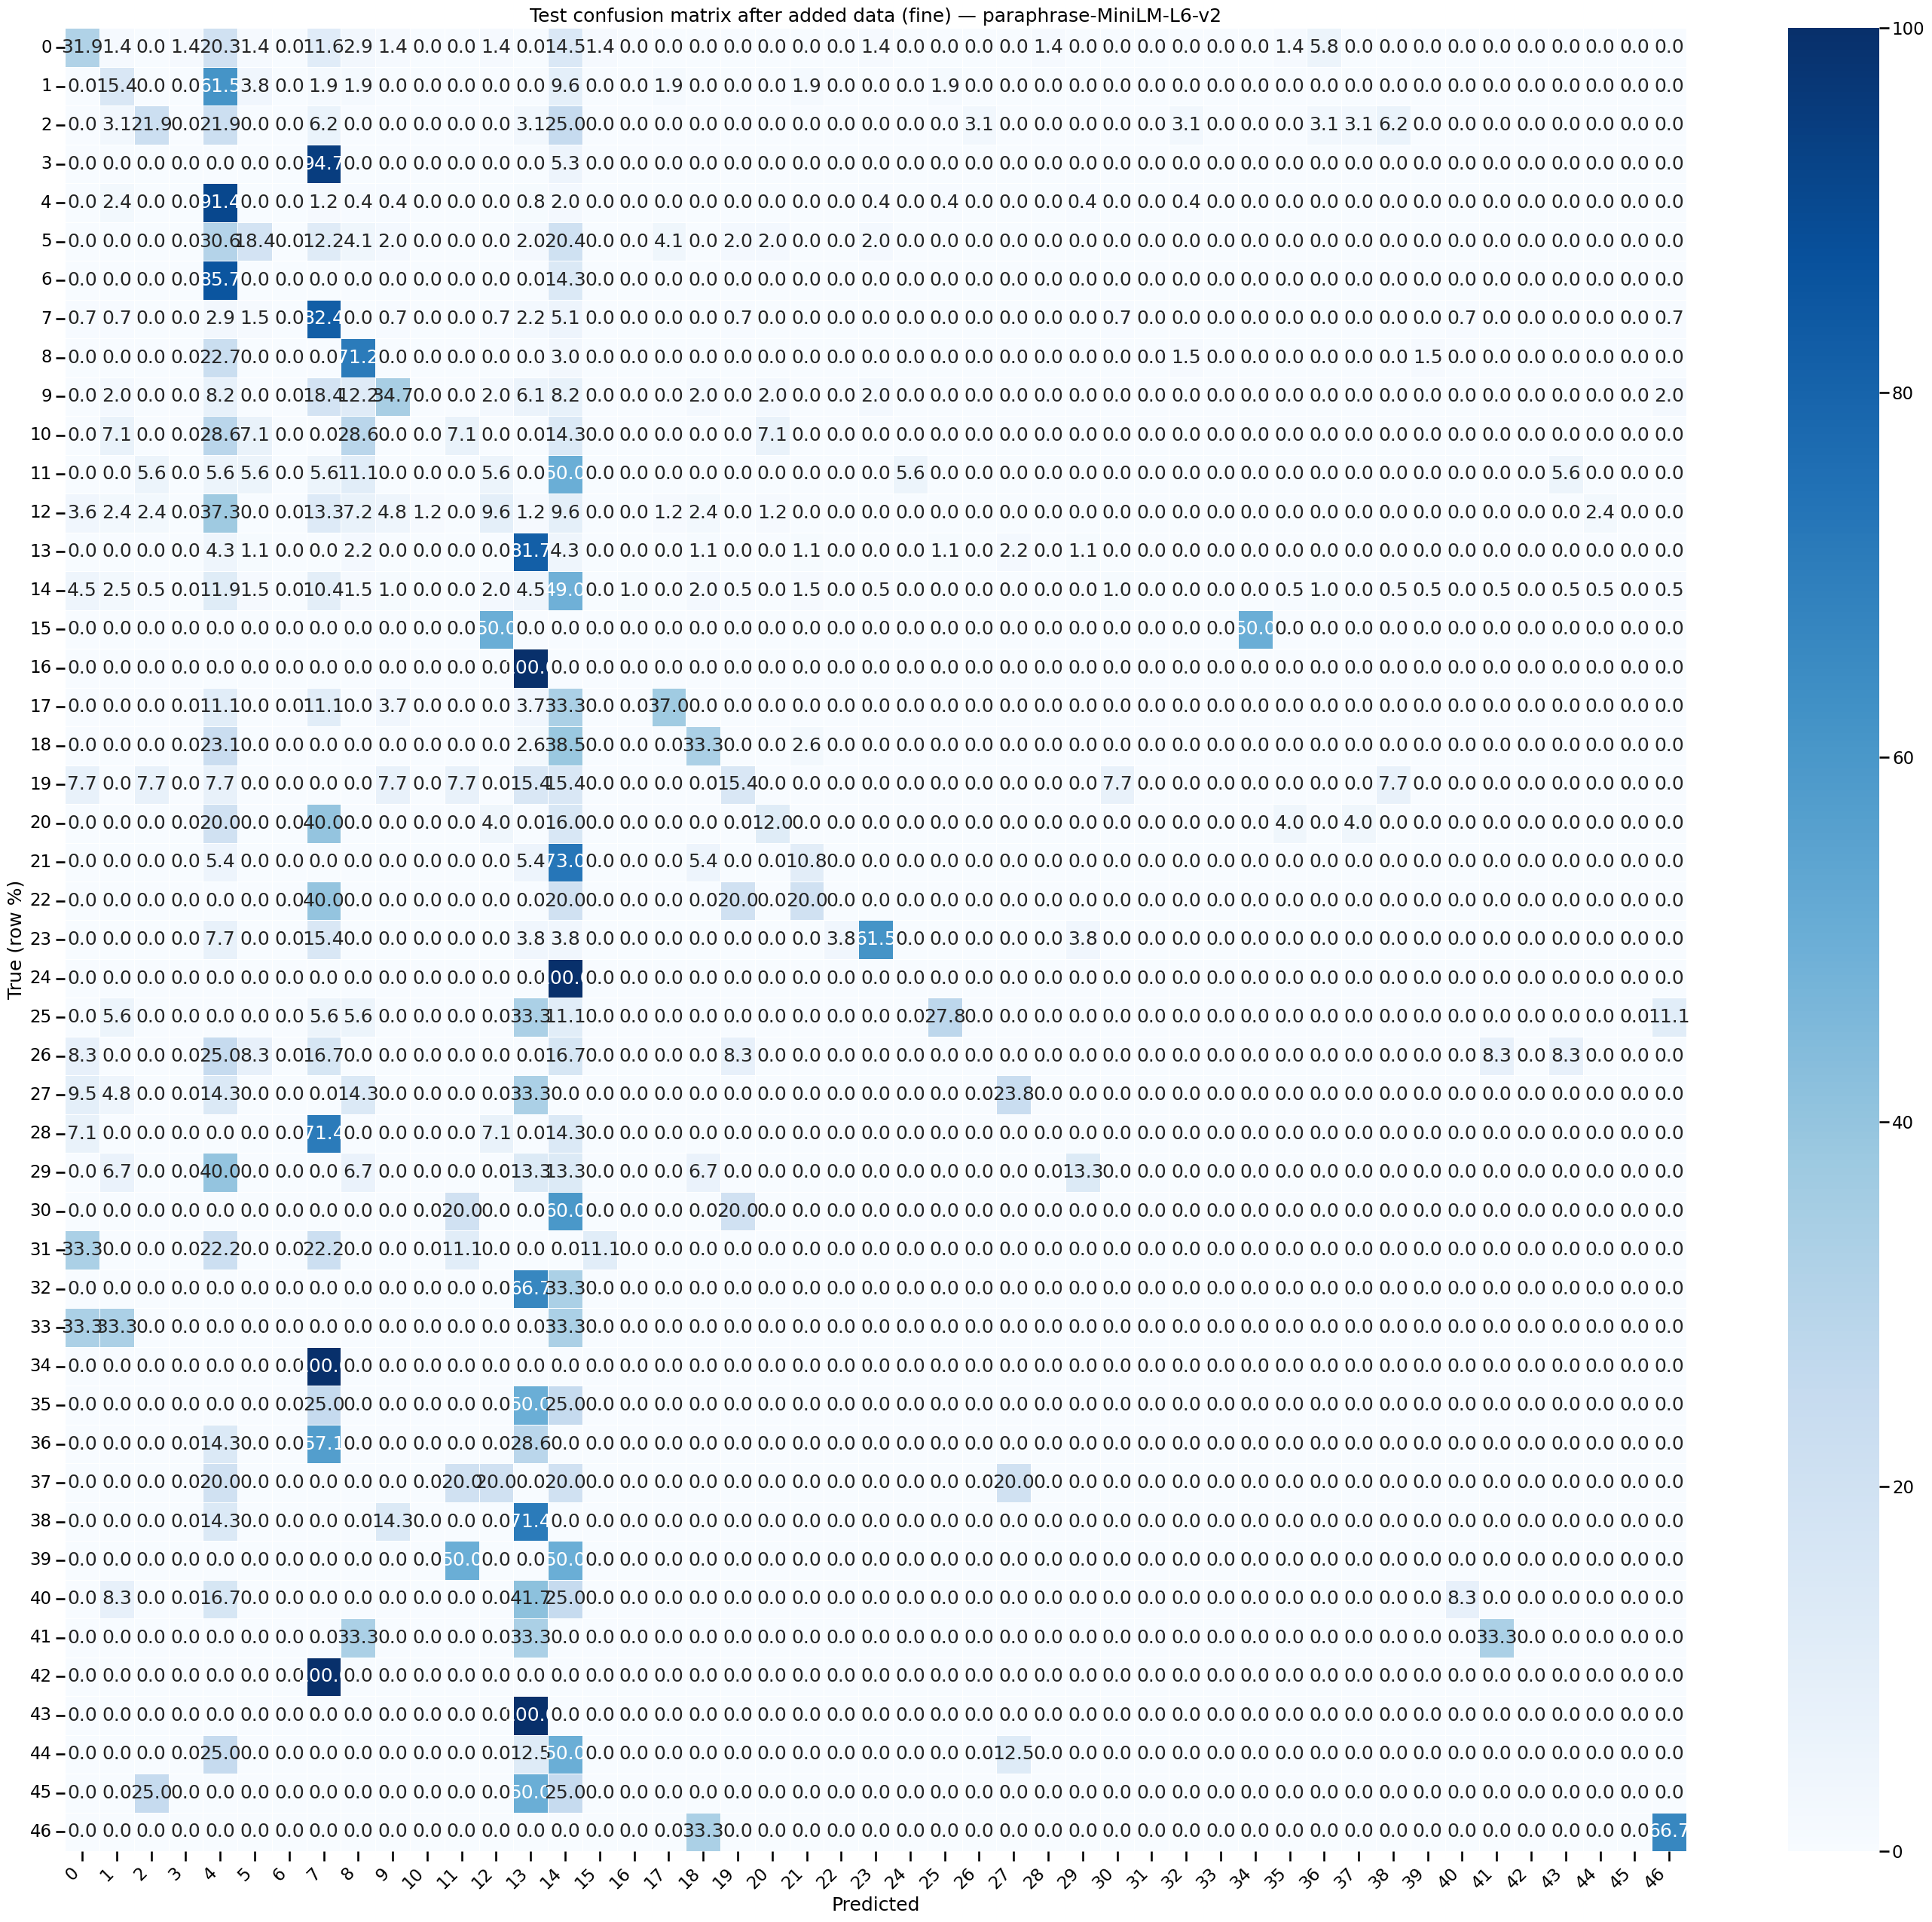

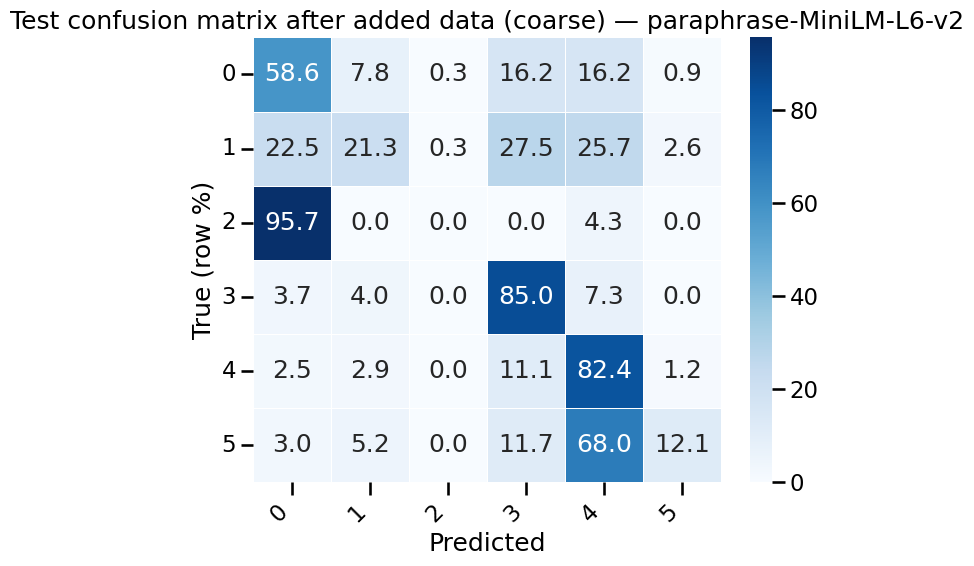

In [19]:
for model_name in embedding_models:
    plot_conf_mat(
        post_artifacts[model_name]["y_test_idx"],
        post_artifacts[model_name]["test_pred_idx"],
        labels=np.arange(len(class_names)),
        title=f"Test confusion matrix after added data (fine) — {model_name}",
        save_path=matrices_dir / f"after_{model_name}_fine.png"
    )

    test_pred_aug_coarse = pd.Series(post_artifacts[model_name]["test_pred_labels"]).map(fine_to_coarse).to_numpy()

    plot_conf_mat(
        y_test_aug_coarse,
        test_pred_aug_coarse,
        labels=class_names_coarse,
        title=f"Test confusion matrix after added data (coarse) — {model_name}",
        save_path=matrices_dir / f"after_{model_name}_coarse.png"
    )

## Step 7: Compare baseline vs retrained results

In [20]:
baseline_results = results_df.copy()
baseline_results["stage"] = "baseline"

post_results_tagged = post_results_df.copy()
post_results_tagged["stage"] = "after_augmentation"

combined_results = pd.concat([baseline_results, post_results_tagged], ignore_index=True)
display(combined_results.sort_values(["model", "stage", "split"]))

,split,accuracy,macro_f1,log_loss,model,embed_time_train_sec,embed_time_test_sec,embed_time_holdout_sec,fit_time_sec,initial_train_loss,final_train_loss,stage
8,holdout,0.247134,0.023670,3.779212,all-MiniLM-L6-v2,1.141262,1.104983,2.083874,0.481937,0.022549,0.019573,after_augmentation
7,test,0.252688,0.022944,3.778057,all-MiniLM-L6-v2,1.141262,1.104983,2.083874,0.481937,0.022549,0.019573,after_augmentation
6,train,0.252336,0.021896,3.777957,all-MiniLM-L6-v2,1.141262,1.104983,2.083874,0.481937,0.022549,0.019573,after_augmentation
2,holdout,0.246304,0.021454,3.778599,all-MiniLM-L6-v2,1.859254,0.749384,2.148447,0.523802,0.022921,0.019563,baseline
1,test,0.247984,0.020306,3.779365,all-MiniLM-L6-v2,1.859254,0.749384,2.148447,0.523802,0.022921,0.019563,baseline
0,train,0.250672,0.023496,3.777066,all-MiniLM-L6-v2,1.859254,0.749384,2.148447,0.523802,0.022921,0.019563,baseline
11,holdout,0.496966,0.176446,3.573709,paraphrase-MiniLM-L6-v2,0.795549,0.908613,1.995456,0.482321,0.064646,0.018588,after_augmentation
10,test,0.471774,0.183714,3.577922,paraphrase-MiniLM-L6-v2,0.795549,0.908613,1.995456,0.482321,0.064646,0.018588,after_augmentation
9,train,0.588117,0.304813,3.528570,paraphrase-MiniLM-L6-v2,0.795549,0.908613,1.995456,0.482321,0.064646,0.018588,after_augmentation
5,holdout,0.495632,0.179875,3.570811,paraphrase-MiniLM-L6-v2,0.857805,0.834661,1.907812,0.479731,0.065001,0.018498,baseline


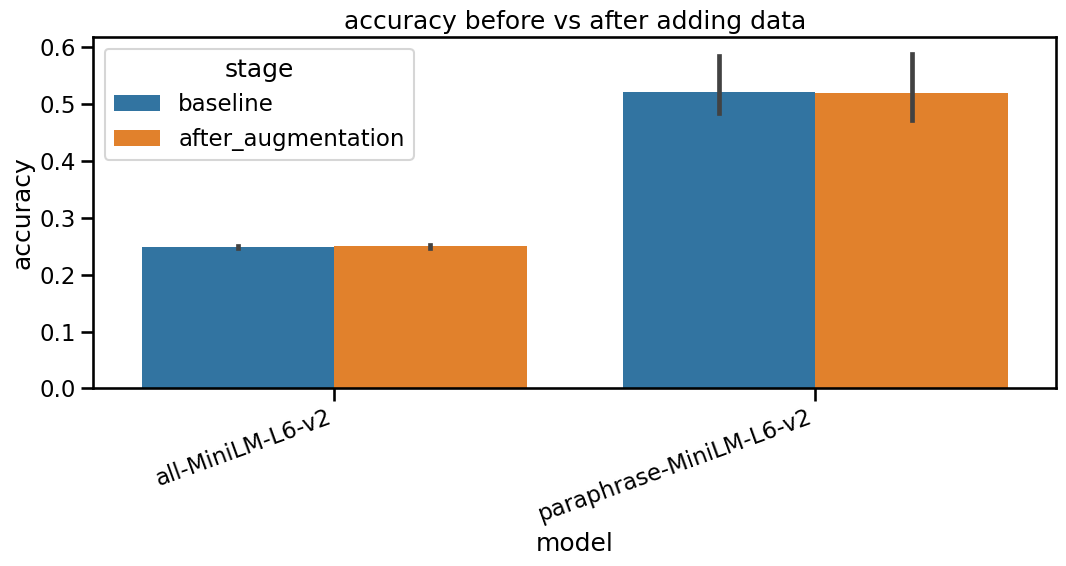

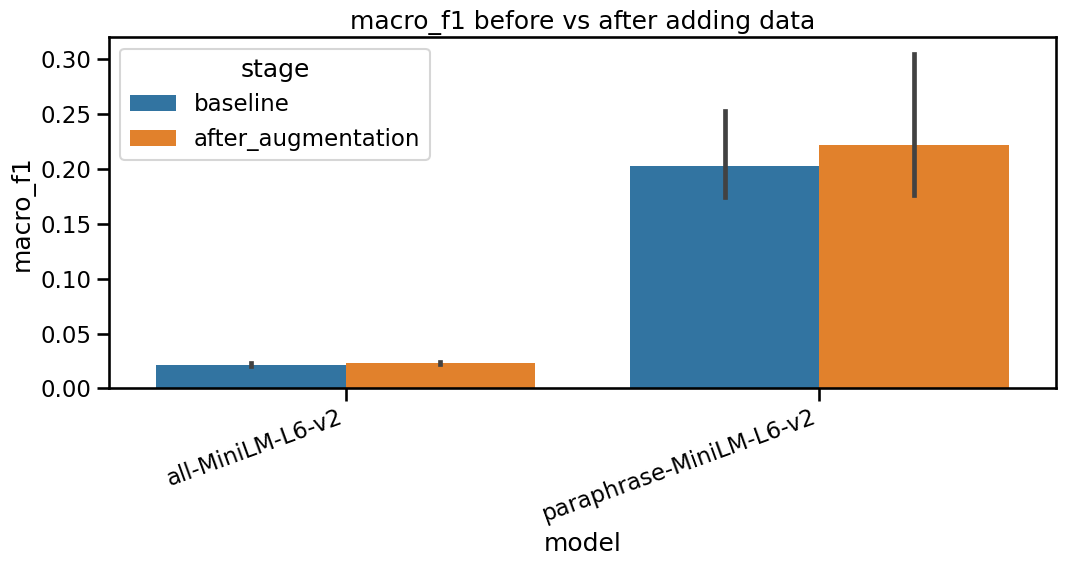

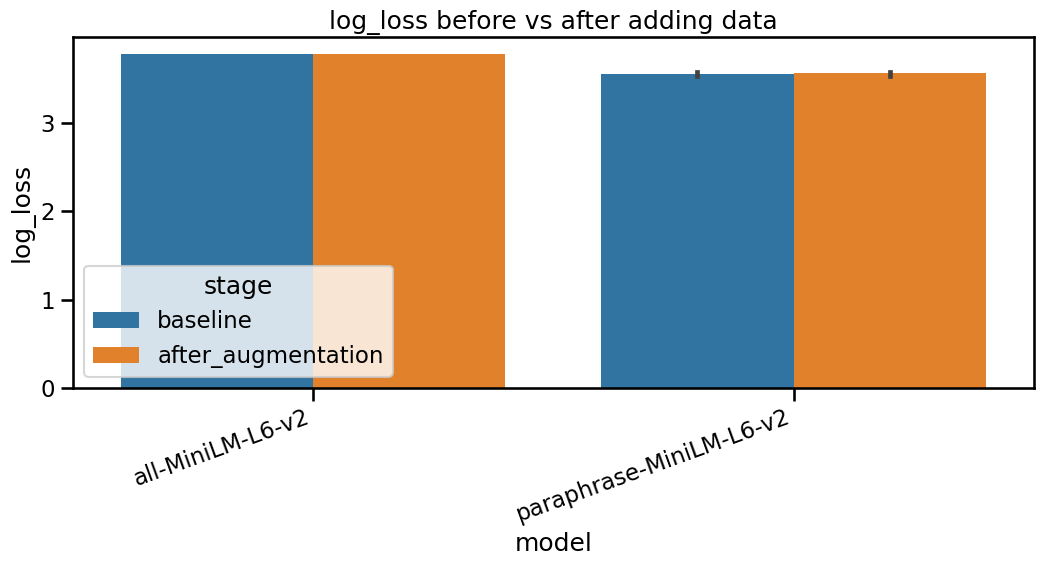

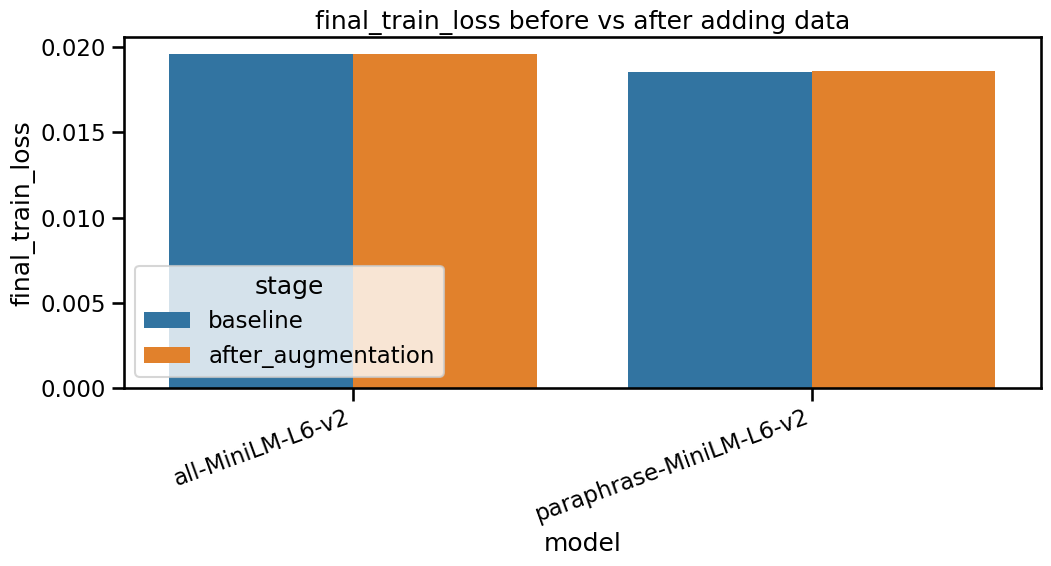

In [21]:
for metric in ["accuracy", "macro_f1", "log_loss", "final_train_loss"]:
    compare_plot_df = combined_results[combined_results["split"].isin(["train", "test", "holdout"])].copy()

    plt.figure(figsize=(11, 6))
    sns.barplot(data=compare_plot_df, x="model", y=metric, hue="stage")
    plt.title(f"{metric} before vs after adding data")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

stage,label-fine,after_augmentation,baseline,change
14,14,0.324059,0.335008,-0.010949
0,0,0.000000,0.000000,0.000000
26,26,0.000000,0.000000,0.000000
27,27,0.000000,0.000000,0.000000
28,28,0.000000,0.000000,0.000000
29,29,0.000000,0.000000,0.000000
30,30,0.000000,0.000000,0.000000
31,31,0.000000,0.000000,0.000000
32,32,0.000000,0.000000,0.000000
33,33,0.000000,0.000000,0.000000


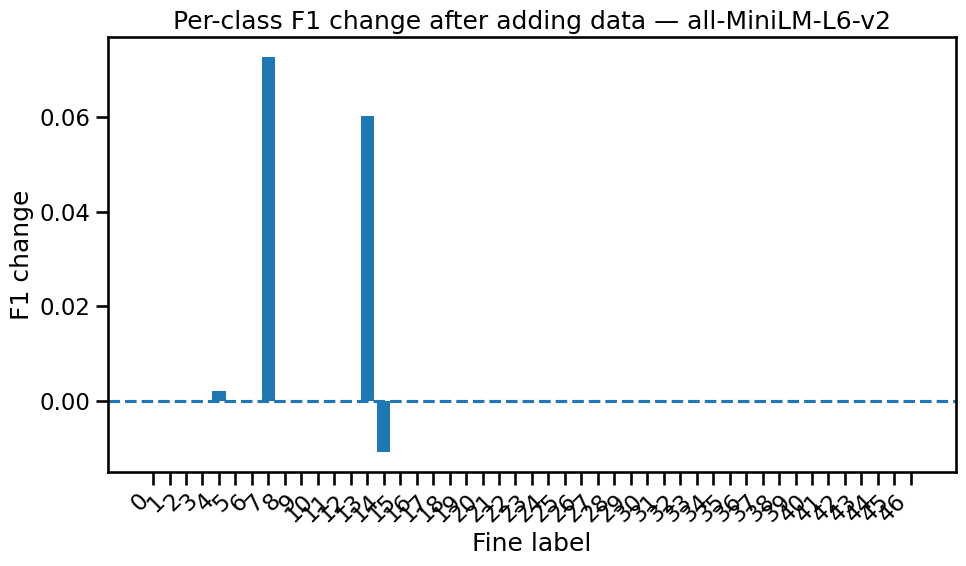

stage,label-fine,after_augmentation,baseline,change
19,19,0.190476,0.521739,-0.331263
21,21,0.166667,0.338462,-0.171795
9,9,0.430380,0.582278,-0.151899
2,2,0.311111,0.452830,-0.141719
26,26,0.000000,0.125000,-0.125000
28,28,0.000000,0.111111,-0.111111
14,14,0.424893,0.495726,-0.070834
0,0,0.389381,0.410256,-0.020876
29,29,0.200000,0.210526,-0.010526
13,13,0.652361,0.658120,-0.005759


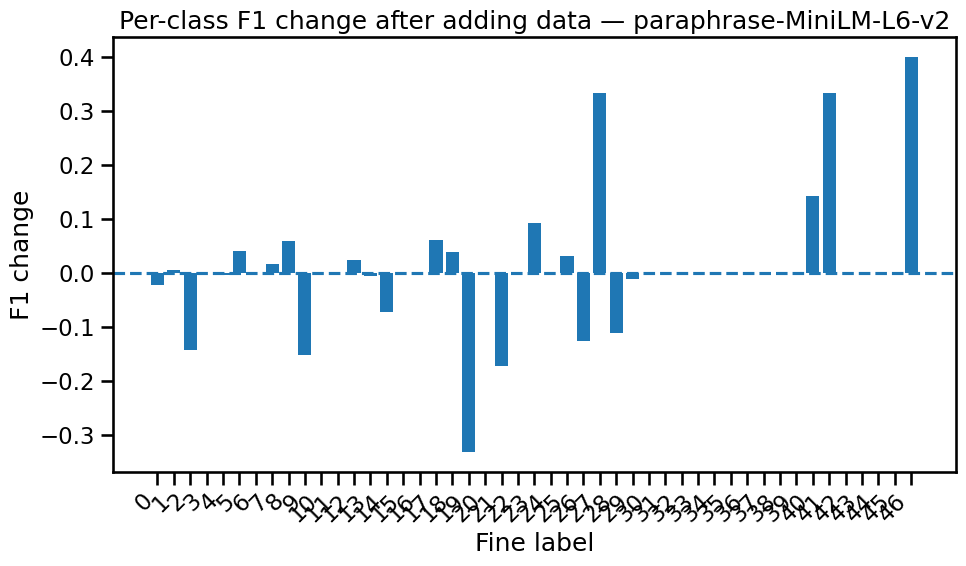

In [22]:
baseline_pc = per_class_df.copy()
post_pc = post_per_class_df.copy()

pc_compare = pd.concat([baseline_pc, post_pc], ignore_index=True)

for model_name in embedding_models:
    model_pc = pc_compare[pc_compare["model"] == model_name]
    pivot = model_pc.pivot(index="label-fine", columns="stage", values="f1-score").reset_index()
    pivot["change"] = pivot["after_augmentation"] - pivot["baseline"]
    display(pivot.sort_values("change"))

    plt.figure(figsize=(10, 6))
    plt.bar(pivot["label-fine"].astype(str), pivot["change"])
    plt.axhline(0, linestyle="--")
    plt.xlabel("Fine label")
    plt.ylabel("F1 change")
    plt.title(f"Per-class F1 change after adding data — {model_name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Optional: custom examples

In [23]:
custom_examples = [
    "Who invented the telescope?",
    "What is the capital of Peru?",
    "When was the internet invented?",
    "Where is the Sahara Desert located?",
]

def predict_custom_examples(model_name, texts, artifact_dict):
    embedder = SentenceTransformer(model_name)
    X_custom = embedder.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    X_custom_tensor = torch.tensor(X_custom, dtype=torch.float32)

    raw_scores, pred_idx = pytorch_model_multiclass_inference(artifact_dict["trained_model"], X_custom_tensor)
    probs = predict_proba_from_scores(raw_scores)

    pred_labels = [class_names[i] for i in pred_idx]
    return pd.DataFrame({
        "text": texts,
        "predicted_label_fine": pred_labels,
        "confidence": probs.max(axis=1),
    })

for model_name in embedding_models:
    print(f"\nCustom predictions — {model_name}")
    display(predict_custom_examples(model_name, custom_examples, post_artifacts[model_name]))


Custom predictions — all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,predicted_label_fine,confidence
0,Who invented the telescope?,4,0.025807
1,What is the capital of Peru?,14,0.023880
2,When was the internet invented?,4,0.024540
3,Where is the Sahara Desert located?,4,0.024356



Custom predictions — paraphrase-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,text,predicted_label_fine,confidence
0,Who invented the telescope?,4,0.036517
1,What is the capital of Peru?,14,0.029763
2,When was the internet invented?,4,0.031630
3,Where is the Sahara Desert located?,14,0.039995


## Short conclusion template

This notebook now follows the codex framing more directly:

- each question embedding is treated as an input vector `x in R^d`,
- each fine label is encoded as a one-hot target `y in R^k`,
- a linear PyTorch model learns the map from embeddings to label scores,
- training uses gradient descent,
- and inference uses `argmax` over the model output. fileciteturn4file2 fileciteturn3file0

So the project still evaluates two embedding models, but the supervised classifier now matches the linear PyTorch workflow taught in the codex instead of relying on `sklearn.LogisticRegression`.
